<a href="https://colab.research.google.com/github/k632412560046/Datathon-Dibi-/blob/main/Datathon_%7C_Dibi_%7C_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c datathon-2026-round-1

import zipfile

with zipfile.ZipFile("datathon-2026-round-1.zip", 'r') as zip_ref:
  zip_ref.extractall("data")

Saving kaggle.json to kaggle.json
100% 27.7M/27.7M [00:00<00:00, 101MB/s] 



In [ ]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
from pathlib import Path
from IPython.display import display

In [ ]:
def clean_transaction_data (orders, order_items, payments, shipments, returns, reviews):
  import pandas as pd
  import numpy as np
  def log_change(df_before, df_after, name, rule):
    removed = len(df_before) - len(df_after)

  # 1. ORDERS
  df = orders.copy()
  df.columns = df.columns.str.strip().str.lower()
  before = df.copy()
  df = df.drop_duplicates()
  log_change(before, df, "ORDERS", "drop duplicates")
  if "order_date" in df.columns:
    before_null = df["order_date"].isna().sum()
    df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
    after_null = df["order_date"].isna().sum()

  for col in ["order_status", "payment_method", "device_type", "order_source"]:
    if col in df.columns:
      df[col] = df[col].astype(str).str.strip().str.lower()

  orders = df

  # 2. ORDER_ITEMS
  df = order_items.copy()
  df.columns = df.columns.str.strip().str.lower()
  for col in ["quantity", "unit_price", "discount_amount"]:
    if col in df.columns:
      df[col] = pd.to_numeric(df[col], errors="coerce")

  before = df.copy()
  df = df.dropna(subset=["order_id", "product_id"])
  log_change(before, df, "ORDER_ITEMS", "drop null keys")

  before = df.copy()
  df = df.drop_duplicates(subset=["order_id", "product_id"])
  log_change(before, df, "ORDER_ITEMS", "drop duplicates")

  before = df.copy()
  df = df[df["quantity"] > 0]
  log_change(before, df, "ORDER_ITEMS", "remove quantity <= 0")

  order_items = df

  # 3. PAYMENTS
  df = payments.copy()
  df.columns = df.columns.str.strip().str.lower()
  df["payment_value"] = pd.to_numeric(df["payment_value"], errors="coerce")

  before = df.copy()
  df = df.drop_duplicates(subset=["order_id"])
  log_change(before, df, "PAYMENTS", "1 order = 1 payment")

  before = df.copy()
  df = df[df["installments"] >= 1]
  log_change(before, df, "PAYMENTS", "remove invalid installments")

  payments = df

  # 4. SHIPMENTS
  df = shipments.copy()

  df.columns = df.columns.str.strip().str.lower()
  df["ship_date"] = pd.to_datetime(df["ship_date"], errors="coerce")
  df["delivery_date"] = pd.to_datetime(df["delivery_date"], errors="coerce")

  before = df.copy()
  df = df.drop_duplicates(subset=["order_id"])
  log_change(before, df, "SHIPMENTS", "1 shipment per order")

  before = df.copy()
  df = df[
    (df["delivery_date"].isna()) |
    (df["delivery_date"] >= df["ship_date"])
  ]
  log_change(before, df, "SHIPMENTS", "invalid date logic")

  shipments = df

  # 5. RETURNS
  df = returns.copy()

  df.columns = df.columns.str.strip().str.lower()
  df["return_date"] = pd.to_datetime(df["return_date"], errors="coerce")

  before = df.copy()
  df = df.drop_duplicates(subset=["return_id"])
  log_change(before, df, "RETURNS", "drop duplicates")

  before = df.copy()
  df = df[df["return_quantity"] > 0]
  log_change(before, df, "RETURNS", "remove quantity <= 0")

  returns = df

  # 6. REVIEWS
  df = reviews.copy()

  df.columns = df.columns.str.strip().str.lower()
  df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")

  before = df.copy()
  df = df.drop_duplicates(subset=["review_id"])
  log_change(before, df, "REVIEWS", "drop duplicates")

  before = df.copy()
  df = df[df["rating"].between(1, 5)]
  log_change(before, df, "REVIEWS", "invalid rating")

  reviews = df

  return orders, order_items, payments, shipments, returns, reviews

In [ ]:
import pandas as pd

# LOAD DATA
orders = pd.read_csv("/content/data/orders.csv")
order_items = pd.read_csv("/content/data/order_items.csv")
payments = pd.read_csv("/content/data/payments.csv")
shipments = pd.read_csv("/content/data/shipments.csv")
returns = pd.read_csv("/content/data/returns.csv")
reviews = pd.read_csv("/content/data/reviews.csv")
customers = pd.read_csv("/content/data/customers.csv")
products = pd.read_csv("/content/data/products.csv")
shipments = pd.read_csv("/content/data/shipments.csv")
geography = pd.read_csv("/content/data/geography.csv")
promotions = pd.read_csv("/content/data/promotions.csv")
sales = pd.read_csv("/content/data/sales.csv")
inventory = pd.read_csv("/content/data/inventory.csv")
web_traffic = pd.read_csv("/content/data/web_traffic.csv")
# CLEAN
orders, order_items, payments, shipments, returns, reviews = clean_transaction_data(
    orders, order_items, payments, shipments, returns, reviews
)

/tmp/ipykernel_29506/301100458.py:5: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv("/content/data/order_items.csv")


# **1. DATA CLEANING AND PREPROCESSING**

In [ ]:
DATA_PATH = "/content/data"
files = glob.glob(f"{DATA_PATH}/*.csv")

dfs = {}
for file in files:
    name = Path(file).stem
    df = pd.read_csv(file, low_memory=False)

    for c in df.columns:
        if 'date' in c.lower():
            try:
                df[c] = pd.to_datetime(df[c])
            except:
                pass

    dfs[name] = df

## **1.1. Standardization**

In [ ]:
def standardize(df):
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower()
    return df

def parse_date(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")
    return df

def to_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def log_change(before, after, name, rule):
    removed = len(before) - len(after)
    pct = (removed / len(before) * 100) if len(before) else 0
    print(f"{name} | {rule}: -{removed} rows ({pct:.2f}%)")

## **1.2. Tables cleaning**

In [ ]:
def clean_transaction_data(orders, order_items, payments, shipments, returns, reviews):

    # ===== ORDERS =====
    df = standardize(orders)
    before = df.copy()
    df = df.drop_duplicates()
    log_change(before, df, "orders", "drop duplicates")

    df = parse_date(df, ["order_date"])

    for col in ["order_status", "payment_method", "device_type", "order_source"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.lower()
    orders = df

    # ===== ORDER ITEMS =====
    df = standardize(order_items)
    df = to_numeric(df, ["quantity", "unit_price", "discount_amount"])

    before = df.copy()
    df = df.dropna(subset=["order_id", "product_id"])
    log_change(before, df, "order_items", "drop null keys")

    before = df.copy()
    df = df.drop_duplicates(subset=["order_id", "product_id"])
    log_change(before, df, "order_items", "drop duplicates")

    before = df.copy()
    df = df[df["quantity"] > 0]
    log_change(before, df, "order_items", "valid quantity")
    order_items = df

    # ===== PAYMENTS =====
    df = standardize(payments)
    df = to_numeric(df, ["payment_value", "installments"])

    before = df.copy()
    df = df.drop_duplicates(subset=["order_id"])
    log_change(before, df, "payments", "1 order = 1 payment")

    before = df.copy()
    df = df[df["installments"] >= 1]
    log_change(before, df, "payments", "valid installments")
    payments = df

    # ===== SHIPMENTS =====
    df = standardize(shipments)
    df = parse_date(df, ["ship_date", "delivery_date"])

    before = df.copy()
    df = df.drop_duplicates(subset=["order_id"])
    log_change(before, df, "shipments", "1 shipment/order")

    before = df.copy()
    df = df[
        (df["delivery_date"].isna()) |
        (df["delivery_date"] >= df["ship_date"])
    ]
    log_change(before, df, "shipments", "valid date logic")
    shipments = df

    # ===== RETURNS =====
    df = standardize(returns)
    df = parse_date(df, ["return_date"])

    before = df.copy()
    df = df.drop_duplicates(subset=["return_id"])
    log_change(before, df, "returns", "drop duplicates")

    before = df.copy()
    df = df[df["return_quantity"] > 0]
    log_change(before, df, "returns", "valid quantity")
    returns = df

    # ===== REVIEWS =====
    df = standardize(reviews)
    df = parse_date(df, ["review_date"])

    before = df.copy()
    df = df.drop_duplicates(subset=["review_id"])
    log_change(before, df, "reviews", "drop duplicates")

    before = df.copy()
    df = df[df["rating"].between(1, 5)]
    log_change(before, df, "reviews", "valid rating")
    reviews = df

    return orders, order_items, payments, shipments, returns, reviews

def clean_inventory(df):
    df = standardize(df)
    df = parse_date(df, ["snapshot_date"])

    df = df.dropna(subset=["snapshot_date", "product_id"])
    df = df.drop_duplicates(subset=["snapshot_date", "product_id"])

    df = to_numeric(df, [
        'stock_on_hand', 'units_received', 'units_sold',
        'stockout_days', 'days_of_supply',
        'fill_rate', 'sell_through_rate'
    ])

    df = df[
        (df['stock_on_hand'] >= 0) &
        (df['units_received'] >= 0) &
        (df['units_sold'] >= 0)
    ]

    df['fill_rate'] = df['fill_rate'].clip(0, 1)
    df['sell_through_rate'] = df['sell_through_rate'].clip(0, 1)

    df['year'] = df['snapshot_date'].dt.year
    df['month'] = df['snapshot_date'].dt.month

    return df

def clean_web_traffic(df):
    df = standardize(df)
    df = parse_date(df, ["date"])

    df = df.dropna(subset=["date", "traffic_source"])
    df = df.drop_duplicates(subset=["date", "traffic_source"])

    df = to_numeric(df, [
        'sessions', 'unique_visitors', 'page_views',
        'bounce_rate', 'avg_session_duration_sec'
    ])

    df = df[
        (df['sessions'] >= 0) &
        (df['unique_visitors'] <= df['sessions']) &
        (df['page_views'] >= df['sessions'])
    ]

    df['bounce_rate'] = df['bounce_rate'].clip(0, 1)

    return df

## **1.3. Data loading**

In [ ]:
DATA_PATH = "/content/data"

def load_data():
    names = [
        "orders","order_items","payments","shipments","returns","reviews",
        "customers","products","geography","promotions","sales",
        "inventory","web_traffic"
    ]
    return {n: pd.read_csv(f"{DATA_PATH}/{n}.csv", low_memory=False) for n in names}

In [ ]:
print(dfs.keys())

dict_keys(['web_traffic', 'products', 'orders', 'shipments', 'sample_submission', 'sales', 'payments', 'reviews', 'promotions', 'order_items', 'customers', 'geography', 'inventory', 'returns'])


In [ ]:
DATA_PATH = "/content/data"
files = glob.glob(f"{DATA_PATH}/*.csv")

# If no files found in /content/data, try a common nested structure
if not files:
    DATA_PATH = "/content/data/datathon-2026-round-1"
    files = glob.glob(f"{DATA_PATH}/*.csv")

dfs = {}
for file in files:
    name = Path(file).stem
    df = pd.read_csv(file, low_memory=False)

    for c in df.columns:
        if 'date' in c.lower():
            try:
                df[c] = pd.to_datetime(df[c])
            except:
                pass

    dfs[name] = df

orders, order_items, payments, shipments, returns, reviews = clean_transaction_data(
    dfs["orders"], dfs["order_items"], dfs["payments"],
    dfs["shipments"], dfs["returns"], dfs["reviews"]
)

inventory = clean_inventory(dfs["inventory"])
web_traffic = clean_web_traffic(dfs["web_traffic"])

orders | drop duplicates: -0 rows (0.00%)
order_items | drop null keys: -0 rows (0.00%)
order_items | drop duplicates: -16 rows (0.00%)
order_items | valid quantity: -0 rows (0.00%)
payments | 1 order = 1 payment: -0 rows (0.00%)
payments | valid installments: -0 rows (0.00%)
shipments | 1 shipment/order: -0 rows (0.00%)
shipments | valid date logic: -0 rows (0.00%)
returns | drop duplicates: -0 rows (0.00%)
returns | valid quantity: -0 rows (0.00%)
reviews | drop duplicates: -0 rows (0.00%)
reviews | valid rating: -0 rows (0.00%)


# **2. EXPLORATORY DATA ANALYSIS**

Để hiểu một cách tổng quan hiệu quả kinh doanh của doanh nghiệp, trước hết, chúng ta sẽ khám phá xu **hướng doanh thu theo thời gian** và xác định các yếu tố ảnh hưởng chính.


Một số câu hỏi trọng tâm:
- Doanh thu có tính mùa vụ (seasonality) hay không?
- Có những giai đoạn tăng/giảm đột ngột nào?
- Những biến động ấy đến từ yếu tố bên ngoài hay bên trong doanh nghiệp?

## **2.1. Revenue**

In [ ]:
sales = pd.read_csv('/content/data/sales.csv', parse_dates=['Date'])
orders = pd.read_csv('/content/data/orders.csv')
promotions = pd.read_csv('/content/data/promotions.csv', parse_dates=['start_date','end_date'])
web = pd.read_csv('/content/data/web_traffic.csv', parse_dates=['date'])

sales.head()

,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


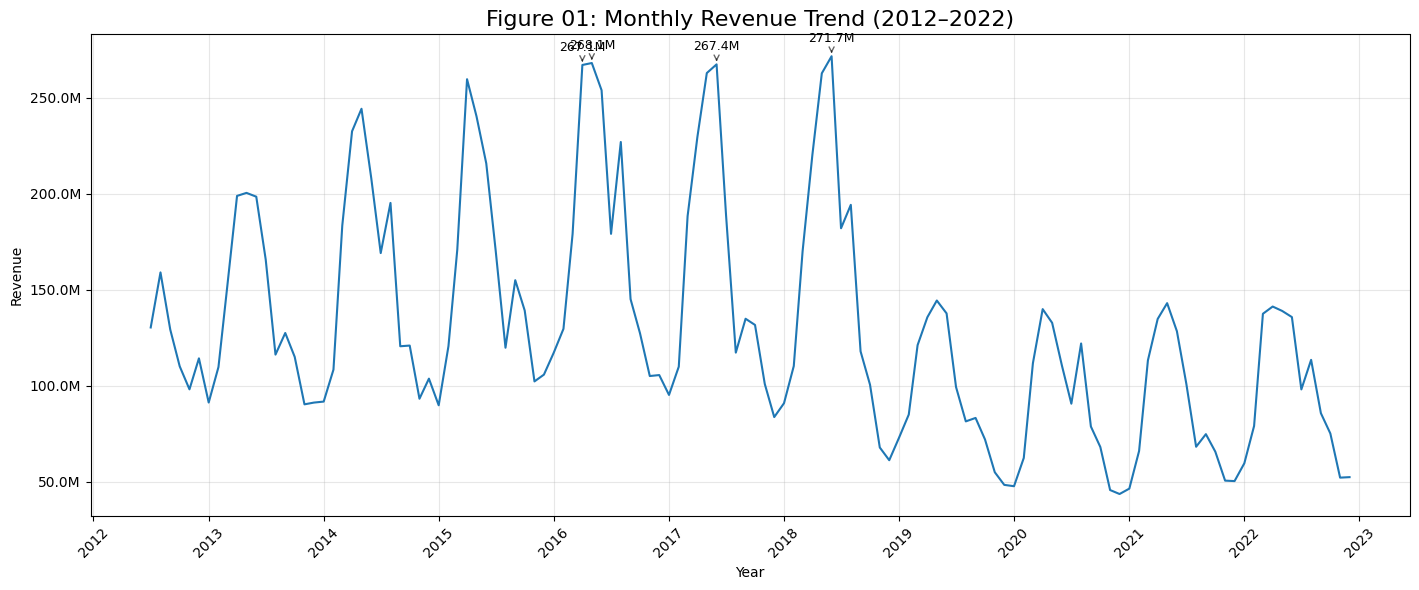

In [ ]:
# Đảm bảo dữ liệu chuẩn
sales['Date'] = pd.to_datetime(sales['Date'])
sales['YearMonth'] = sales['Date'].dt.to_period('M')

# Tạo monthly_revenue
monthly_revenue = sales.groupby('YearMonth')['Revenue'].sum()

# Convert index (an toàn hơn)
if isinstance(monthly_revenue.index, pd.PeriodIndex):
  monthly_revenue.index = monthly_revenue.index.to_timestamp()

# Plot
plt.figure(figsize=(14,6))
plt.plot(monthly_revenue.index, monthly_revenue.values)

# Format trục thời gian
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

#Highlight top peaks
top_n = 4
top_peaks = monthly_revenue.nlargest(top_n)
for date, value in top_peaks.items():
    ax.annotate(
        f'{value*1e-6:.1f}M',
        xy=(date, value),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        fontsize=9,
        arrowprops=dict(arrowstyle='->', alpha=0.6)
    )

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.title("Figure 01: Monthly Revenue Trend (2012–2022)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.tight_layout()

import matplotlib.ticker as ticker

def format_millions(x, pos):
    return f'{x*1e-6:.1f}M'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_millions))

plt.show()

**MÔ TẢ:** Biểu đồ thể hiện xu hướng tổng doanh thu theo từng tháng của doanh nghiệp trong giai đoạn từ 07/2012-12/2022. Ta thấy:
- Doanh thu **dao động mạnh** trong khoảng từ 50M đến 271M.
- Tình hình doanh thu chia làm 02 giai đoạn rõ rệt:
  + 2012-2018: Doanh thu tăng trưởng mạnh mẽ với các đỉnh sau cao hơn các đỉnh trước.
  + 2019-2022: Doanh thu sụt giảm nghiêm trọng và đi ngang ở mức thấp, các đỉnh giảm gần 50% so với cùng kỳ giai đoạn trước.

**GIẢ THUYẾT:** Khi đỉnh sụt giảm một cách nghiêm trọng thì phải do một vấn đề lớn nào đó phát sinh. 2019-2022 là thời điểm xảy ra Covid-19 nên đây sẽ là một điểm chúng ta có thể kiểm chứng sâu hơn.

### **Kiểm chứng yếu tố vĩ mô ngoại vi: Covid 19**

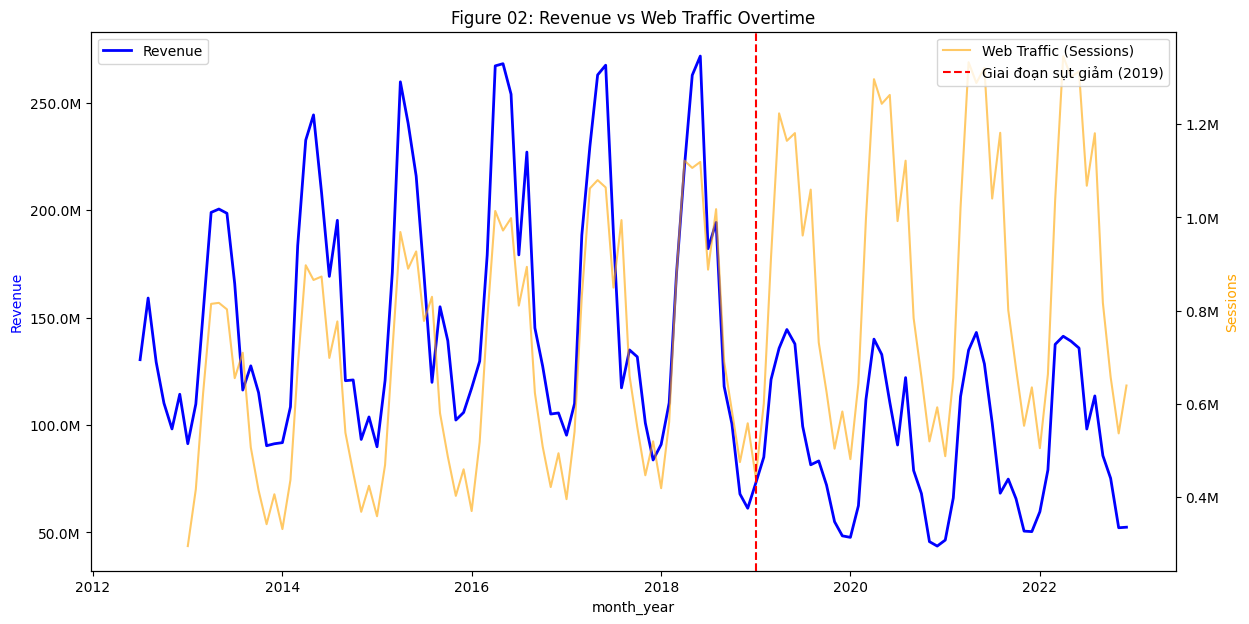

Bảng ma trận tương quan:
Revenue            1.000000
sessions           0.457834
stock_on_hand     -0.182083
conversion_rate    0.588806
Name: Revenue, dtype: float64


In [ ]:
# 1. Tiền xử lý thời gian:
# sales.csv dùng 'Date'
sales['Date'] = pd.to_datetime(sales['Date'])
# web_traffic.csv dùng 'date'
web_traffic['date'] = pd.to_datetime(web_traffic['date'])
# inventory.csv dùng 'snapshot_date'
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])

# Tạo cột Tháng-Năm để Groupby
sales['month_year'] = sales['Date'].dt.to_period('M')
web_traffic['month_year'] = web_traffic['date'].dt.to_period('M')
inventory['month_year'] = inventory['snapshot_date'].dt.to_period('M')

# 2. Aggregation (Tổng hợp dữ liệu theo tháng)
# Doanh thu hàng tháng (Dùng cột 'Revenue' viết hoa theo đề bài)
monthly_revenue = sales.groupby('month_year')['Revenue'].sum().reset_index()

# Traffic hàng tháng (Sessions)
monthly_traffic = web_traffic.groupby('month_year')['sessions'].sum().reset_index()

# Tồn kho hàng tháng (Do bảng inventory ghi nhận tồn kho của từng sản phẩm nên sum lại theo tháng)
monthly_inventory = inventory.groupby('month_year')['stock_on_hand'].sum().reset_index()

# 3. Merge (Gộp các bảng lại làm một)
df_merged = monthly_revenue.merge(monthly_traffic, on='month_year', how='left')
df_merged = df_merged.merge(monthly_inventory, on='month_year', how='left')

# Chuyển month_year về dạng datetime để vẽ đồ thị
df_merged['month_year'] = df_merged['month_year'].dt.to_timestamp()

# 4. Tính toán các chỉ số chẩn đoán (Diagnostic Metrics)
# Tỷ lệ chuyển đổi (Conversion Rate): Revenue / Sessions
df_merged['conversion_rate'] = (df_merged['Revenue'] / df_merged['sessions']) * 100

# 5. Trực quan hóa so sánh
fig, ax1 = plt.subplots(figsize=(14, 7))

# Vẽ Revenue
sns.lineplot(data=df_merged, x='month_year', y='Revenue', ax=ax1, label='Revenue', color='blue', linewidth=2)
ax1.set_ylabel('Revenue', color='blue')

# Tạo trục thứ 2 để vẽ Traffic
ax2 = ax1.twinx()
sns.lineplot(data=df_merged, x='month_year', y='sessions', ax=ax2, label='Web Traffic (Sessions)', color='orange', alpha=0.6)
ax2.set_ylabel('Sessions', color='orange')

# Thêm đường kẻ đánh dấu mốc năm 2018
plt.axvline(pd.Timestamp('2019-01-01'), color='red', linestyle='--', label='Giai đoạn sụt giảm (2019)')

plt.title('Figure 02: Revenue vs Web Traffic Overtime')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

import matplotlib.ticker as ticker

def format_millions(x, pos):
    return f'{x*1e-6:.1f}M'

ax1.yaxis.set_major_formatter(ticker.FuncFormatter(format_millions))

def format_sessions(x, pos):
    return f'{x*1e-6:.1f}M'

ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_sessions))

plt.show()

# 6. Kiểm tra tương quan số học
correlation = df_merged[['Revenue', 'sessions', 'stock_on_hand', 'conversion_rate']].corr()
print("Bảng ma trận tương quan:")
print(correlation['Revenue'])


**MÔ TẢ:** Biểu đồ thể hiện xu hướng vận động của doanh thu (Revenue - đường màu xanh) và lượng truy cập (Web Traffic - đường màu vàng). Ta thấy:
- Trước 2019 - **Đồng pha**: Revenue và Web traffic di chuyển cực kỳ đồng điệu và đạt đỉnh cùng lúc.
- Sau 2019 - **Lệch pha**: Sự bất thường xảy ra khi Web Traffic tiếp tục tăng cao rõ rệt, tạo ra những đỉnh lịch sử mới cao hơn hẳn giai đoạn trước. Thế nhưng, doanh thu lại tụt dốc không phanh, các đỉnh đều không vượt quá 150M.

**GIẢI THÍCH:** Sự bùng nổ của Web Traffic có thể được lý giải bởi Covid-19 khi thay đổi hành vi mua sắm của khách hàng, khiến người dùng lướt web nhiều hơn để giải trí.

**GIẢ THUYẾT:** Tuy nhiên, tại sao lại xảy ra sự lệch pha khiến Revenue sụt giảm đáng kinh ngạc như vậy? Ta đặt ra 02 giả thuyết về nguyên nhân:

**1. Nguyên nhân ngoại vi:** Covid-19 khiến tình hình kinh tế bất ổn, khách hàng có ít nhu cầu mua sắm hơn dù có xu hướng lướt web nhiều hơn do thời lượng ở nhà tăng cao.

**2. Nguyên nhân nội tại:** Các nguyên nhân ở phía doanh nghiệp (sản phẩm, vận hành,...) mới là yếu tố quyết định đến sự sụt giảm rõ rệt trong doanh thu như vậy.

**KIỂM CHỨNG:**

**1. Nguyên nhân ngoại vi:** Theo báo cáo Ngành Thời trang trong Ngành Hàng Tiêu dùng, tổng doanh thu ngành tăng mạnh trong giai đoạn 2019-2022, điều này thể hiện rõ ràng rằng nhu cầu mua sắm của người dùng tăng mạnh. Như vậy, Covid-19 không phải là nguyên nhân gây ra sự suy thoái trong tổng doanh thu ngành về mặt vĩ mô. Tuy nhiên, vẫn nên coi đây là một yếu tố có thể ảnh hưởng đến hành vi khách hàng như: gu ăn mặc, phương thức thanh toán,...

**2. Nguyên nhân nội tại:** Dựa vào các dữ liệu đã có sẵn, chúng ta sẽ tiến hành kiểm chứng 02 khía cạnh chính:
- Danh mục sản phẩm
- Hàng tồn kho



### **Kiểm chứng yếu tố nội tại doanh nghiệp: DANH MỤC SẢN PHẨM**

### Sản lượng & Doanh thu

In [ ]:
df_product_sales = order_items.merge(
    dfs['products'][['product_id', 'product_name', 'category']],
    on='product_id',
    how='left'
).merge(
    orders[['order_id', 'order_date']],
    on='order_id',
    how='left'
)

df_product_sales['order_date'] = pd.to_datetime(df_product_sales['order_date'])

df_product_sales['net_revenue'] = (df_product_sales['quantity'] * df_product_sales['unit_price']) - df_product_sales['discount_amount']

#QUANTITY BY CATEGORY OVERTIME
df_product_sales['month'] = df_product_sales['order_date'].dt.to_period('M').dt.to_timestamp()

qty_time = (
    df_product_sales.groupby(['month', 'category'])['quantity']
      .sum()
      .reset_index()
)

fig = px.line(
    qty_time,
    x='month',
    y='quantity',
    color='category',
    title='Figure 03: Quantity by Category Over Time'
)

fig.show()

#REVENUE BY CATEGORY OVERTIME

rev_time_line_plot = (
    df_product_sales.groupby(['month', 'category'])['net_revenue']
      .sum()
      .reset_index()
)

fig = px.line(
    rev_time_line_plot,
    x='month',
    y='net_revenue',
    color='category',
    title='Figure 04: Net Revenue by Category Over Time'
)

fig.show()

# REVENUE SHARE BY CATEGORY OVERTIME (%)
# revenue theo time
rev_time = (
    df_product_sales.groupby(['month', 'category'])['net_revenue']
      .sum()
      .reset_index()
)

# pivot để tính %
rev_pivot = rev_time.pivot(index='month', columns='category', values='net_revenue').fillna(0)

# chuyển thành %
rev_pct = rev_pivot.div(rev_pivot.sum(axis=1), axis=0) * 100

# back to long format
rev_pct = rev_pct.reset_index().melt(
    id_vars='month',
    var_name='category',
    value_name='pct'
)

# plot
fig = px.area(
    rev_pct,
    x='month',
    y='pct',
    color='category',
    title='Figure 05: Revenue Share by Category Over Time (%)'
)

fig.show()

In [ ]:
cat_time = qty_time.merge(rev_time_line_plot, on=['month', 'category'])
cat_time['rev_per_unit'] = cat_time['net_revenue'] / cat_time['quantity']

fig = px.scatter(
    cat_time,
    x='quantity',
    y='net_revenue', # Changed from 'revenue' to 'net_revenue'
    color='category',
    size='rev_per_unit',
    animation_frame='month',
    title='Figure 06: Category Positioning Over Time (Volume vs Revenue)'
)

fig.show()

In [ ]:
def category_share_analysis(order_items, products):

    df = order_items.merge(
        products[['product_id', 'category']],
        on='product_id',
        how='left'
    )

    df['revenue'] = df['quantity'] * df['unit_price']

    cat = df.groupby('category').agg(
        total_quantity=('quantity', 'sum'),
        total_revenue=('revenue', 'sum')
    ).reset_index()

    cat['total_revenue'] = cat['total_revenue'] / 1_000_000

    cat['qty_share_%'] = cat['total_quantity'] / cat['total_quantity'].sum() * 100
    cat['rev_share_%'] = cat['total_revenue'] / cat['total_revenue'].sum() * 100

    cat['share_gap_%'] = cat['rev_share_%'] - cat['qty_share_%']
    cat['avg_price'] = cat['total_revenue'] * 1_000_000 / cat['total_quantity']  # giữ đơn vị gốc

    cat = cat.round(2).sort_values(by='total_revenue', ascending=False)

    cat = cat.rename(columns={
        'total_quantity': 'total_quantity (units)',
        'total_revenue': 'total_revenue (M)',
        'qty_share_%': 'quantity_share (%)',
        'rev_share_%': 'revenue_share (%)',
        'share_gap_%': 'share_gap (%)',
        'avg_price': 'avg_price (per unit)'
    })

    print("Figure 07: Category Analysis Table")
    display(cat)

    return cat

cat_summary = category_share_analysis(order_items, dfs['products'])

Figure 07: Category Analysis Table


,category,total_quantity (units),total_revenue (M),quantity_share (%),revenue_share (%),share_gap (%),avg_price (per unit)
3,Streetwear,1768796,13131.18,55.05,79.92,24.87,7423.79
2,Outdoor,1169983,2494.86,36.41,15.18,-21.23,2132.39
0,Casual,107469,460.65,3.34,2.80,-0.54,4286.34
1,GenZ,166833,343.58,5.19,2.09,-3.10,2059.41


**MÔ TẢ:** Các biểu đồ trên thể hiện xu hướng của sản lượng (Quantity) và doanh thu (Revenue) theo từng danh mục sản phẩm. Ta nhận thấy:
- Streetwear:
  + Chiếm phần lớn ở cả sản lượng (55%) và revenue (80%). Với share_gap rất lớn gần 25%, tạo ra giá trị thặng dư lớn về lợi nhuận cho doanh nghiệp, ta có thể lý giải tại sao doanh nghiệp đã tập trung vào sản xuất mặt hàng này.
  + Tuy nhiên, các chỉ số trên cũng thể hiện rằng doanh nghiệp đang tập trung gần như toàn bộ nguồn lực vào mặt hàng này (80%), điều này sẽ tạo ra một rủi ro lớn khi **"bỏ trứng vào cùng một giỏ"** một khi gu thẩm mỹ của khách hàng thay đổi hoặc có các yếu tố khác tác động. Rủi ro này đã được chứng minh khi có một sự sụt giảm đột ngột xảy ra kể từ 2019, thể hiện sự mong manh của cơ cấu sản phẩm trước thay đổi của môi trường và người dùng.
  + Một rủi ro nữa cũng được thể hiện rõ trong biểu đồ khi Streetwear quá mang tính thời vụ với dao động cực mạnh hàng năm (đạt đỉnh tại >250M vào tháng 4,5 và chạm đáy tại <50M vào tháng 12), khiến doanh thu thường không ổn định. Kết hợp với việc Streetwear chiếm gần như toàn bộ thị phần, doanh thu của doanh nghiệp sẽ phụ thuộc rất lớn vào nguồn thu không ổn định ấy.
  + Kết hợp với yếu tố Covid-19 đã phân tích ở trên, ta có thể "ngầm hiểu": người dùng không có nhu cầu sử dụng Streetwear khi phải ở nhà nhiều hơn. Bên cạnh đó, đây cũng là mặt hàng đã bước vào giai đoạn suy thoái trong Product Life Cycle của nó, khi thị trường đã đạt đỉnh nhu cầu và Streetwear không còn là xu hướng.
  
  **=> Kết luận:** Doanh nghiệp không nên tiếp tục coi Streetwear là động cơ tăng trường mà nên chuyển nguồn lực sang tập trung phát triển các danh mục sản phẩm khác. Tuy nhiên, đây vẫn là một hạng mục tạo ra share_gap lớn nên vẫn có thể duy trì một lượng thị phần nhất định để làm dự phòng doanh thu trước khi các mặt hàng tiếp theo có sự phát triển bùng nổ.


- Outdoor:
  + Outdoor có sản lượng khá cao (36%), nhưng liên tục suy giảm theo thời gian.
  + Có thể thấy sự sụt giảm rõ rệt trong doanh thu. Với share_gap âm lớn (-21%), ta có thể thấy đây không phải mặt hàng tạo ra giá trị lợi nhuận cho doanh nghiệp.
  + Outdoor đã từng thực hiện khá tốt nhiệm vụ của một mặt hàng thay thế với thị phần tương đối và vận động ngược pha với Streetwear, tạo ra các nguồn doanh thu bù đắp khi đạt đỉnh vào các tháng Streetwear chạm đáy. Tuy nhiên, đây không phải một mặt hàng tiềm năng khi rơi vào cùng tình cảnh với Streetwear kể từ giai đoạn sau 2018, thậm chí có sự suy thoái và giảm giá trị rõ ràng hơn.
  + Outdoor có thể gặp cùng tình trạng với Streetwear khi nhu cầu người tiêu dùng đã dịch chuyển, bên cạnh đó, ta có thể kiểm chứng thêm một khả năng: Overstock (tồn kho dư thừa) khi doanh nghiệp sản xuất nhiều hơn nhu cầu thực tế.

  **=> Kết luận:** Doanh nghiệp nên cắt giảm nguồn lực trong việc sản xuất và kinh doanh Outdoor khi nó mang lại giá trị âm. Mức độ cắt giảm sẽ phụ thuộc vào tình hình kiểm chứng hàng tồn kho: **cắt giảm một phần** nếu nguyên nhân chính nằm ở việc tồn kho dư thừa, khi đó doanh nghiệp có thể tối ưu sản lượng về đúng với nhu cầu thực tế và **cắt giảm hoàn toàn** nếu vấn đề chính nằm ở nhu cầu người dùng và sản phẩm không còn mang lại giá trị.

- Casual & GenZ:
  + Đây là mặt hàng không được doanh nghiệp tập trung kinh doanh với thị phần rất nhỏ ở cả Quantity và Revenue.
  + Tuy nhiên, khi nhìn vào các biểu đồ, ta thấy có sự tăng nhẹ qua từng năm, thể hiện tiềm năng lớn.
  + Hai mặt hàng này đồng thời không thể hiện yếu điểm là **tính mùa vụ ** khi không bị dao động quá mạnh bởi các mặt hàng trong năm.
  + Bên cạnh đó, đây là hai danh mục sản phẩm **không bị ảnh hưởng** sau 2019, thể hiện sự ổn định trong nhu cầu khách hàng cũng như khó bị tác động bởi các yếu tố vĩ mô.

  => **Kết luận:** Casual & GenZ là hai danh mục sản phẩm cần được mở rộng sản xuất.





In [ ]:
def category_growth_analysis(order_items_df, products_df, shipments_df):
    # Merge data
    df = order_items_df.merge(
        products_df[['product_id', 'category']],
        on='product_id',
        how='left'
    ).merge(
        shipments_df[['order_id', 'ship_date']],
        on='order_id',
        how='left'
    )

    df['ship_date'] = pd.to_datetime(df['ship_date'])
    df['year'] = df['ship_date'].dt.year
    df['revenue'] = df['quantity'] * df['unit_price'] # Assuming unit_price is after discount

    yearly_rev = (
        df.groupby(['year', 'category'])['revenue']
        .sum()
        .unstack()
        .fillna(0)
        .sort_index()
    )

    # CAGR
    def calculate_cagr(series):
        s = series.replace(0, np.nan).dropna() # Remove zeros and NaNs
        if len(s) < 2:
            return np.nan

        start_val = s.iloc[0]
        end_val = s.iloc[-1]
        n_years = len(s) - 1

        if start_val <= 0: # Avoid division by zero or negative base for CAGR
            return np.nan

        return (end_val / start_val) ** (1 / n_years) - 1

    # Metrics calculation
    cagr = yearly_rev.apply(calculate_cagr)
    total_rev = yearly_rev.sum()
    rev_share = total_rev / total_rev.sum()

    # Growth volatility (sd of Year-over-Year growth)
    yoy_growth = yearly_rev.pct_change()
    volatility = yoy_growth.std()

    # Momentum (Recent trend: average of last 2 years vs. first 2 years)
    # Using more robust calculation for momentum, checking for enough data points
    momentum = pd.Series(dtype=float)
    for col in yearly_rev.columns:
        series = yearly_rev[col].replace(0, np.nan).dropna()
        if len(series) >= 4: # Need at least 4 years for 2 recent and 2 initial
            recent_avg = series.iloc[-2:].mean()
            initial_avg = series.iloc[:2].mean()
            if initial_avg > 0: # Avoid division by zero
                momentum[col] = (recent_avg / initial_avg) - 1
            else:
                momentum[col] = np.nan
        else:
            momentum[col] = np.nan

    # Report
    report = pd.DataFrame({
        'total_revenue': total_rev,
        'revenue_share_%': rev_share * 100,
        'cagr_%': cagr * 100,
        'volatility': volatility,
        'momentum_%': momentum * 100
    }).round(2)

    report = report.sort_values(by='total_revenue', ascending=False)

    # Classification
    def classify(row):
        if pd.isna(row['cagr_%']) or pd.isna(row['volatility']) or pd.isna(row['momentum_%']):
            return 'Insufficient Data'
        elif row['cagr_%'] > report['cagr_%'].median() and row['volatility'] < report['volatility'].median():
            return 'Star (High Growth - Stable)'
        elif row['cagr_%'] > report['cagr_%'].median():
            return 'Risky Growth (High Growth - Volatile)'
        elif row['momentum_%'] < 0:
            return 'Declining'
        else:
            return 'Mature/Stable'

    report['segment'] = report.apply(classify, axis=1)

    print("\nFigure 08: Category Strategic Analysis")
    display(report.drop(columns=['total_revenue']))

    # 7. Visulization

    # NORMALIZED GROWTH (INDEX = 100)
    norm = yearly_rev.copy()
    for col in norm.columns:
        if norm[col].iloc[0] > 0:
            norm[col] = (norm[col] / norm[col].iloc[0]) * 100
        else:
            norm[col] = np.nan # If starting value is 0, cannot normalize

    norm_long = norm.reset_index().melt(
        id_vars='year', var_name='category', value_name='index'
    )

    fig2 = px.line(
        norm_long.dropna(), # Drop categories with NaN due to normalization issues
        x='year',
        y='index',
        color='category',
        title='Figure 09: Growth Index by Category (Base = 100)'
    )
    fig2.show()

    # CAGR vs VOLATILITY
    fig3 = px.scatter(
        report.reset_index().dropna(subset=['cagr_%', 'volatility']), # Only plot if both metrics are available
        x='volatility',
        y='cagr_%',
        color='index',
        text='index',
        size='total_revenue',
        title='Figure 10: Growth (CAGR) vs Stability (Volatility)'
    )
    fig3.update_traces(textposition='top center')
    fig3.show()

    return report, yearly_rev

# Call the function with the cleaned dataframes
category_report, yearly_revenue_data = category_growth_analysis(order_items, dfs['products'], shipments)


Figure 08: Category Strategic Analysis


,revenue_share_%,cagr_%,volatility,momentum_%,segment
Streetwear,79.95,5.62,0.45,-1.56,Declining
Outdoor,15.16,-4.37,0.39,-58.01,Declining
Casual,2.79,16.43,0.48,144.54,Risky Growth (High Growth - Volatile)
GenZ,2.10,11.69,0.64,50.72,Risky Growth (High Growth - Volatile)


**KIỂM CHỨNG:** Các chỉ số đã tính toán trên kiểm chứng cho các kết luận ở phần trước, trong đó:
- CAGR (Compound Annual Growth Rate - Tốc độ tăng trưởng kép) phản ánh xu hướng tăng trưởng dài hạn của từng danh mục, trong đó:
  + Streetwear có tăng trưởng dương (5,62%) nhưng không cao, cho thấy đây **không còn là động lực tăng trưởng chính**. Figure 03, 04, 09 cho thấy phần lớn tăng trưởng đến từ giai đoạn trước 2019 còn sau đó là giai đoạn suy thoái.
  + Outdoor có CAGR âm (-4,37%), kết hợp với các phân tích và biểu đồ trước đó, ta thấy được **xu hướng suy giảm dài hạn rõ rệt**.
  + Casual & GenZ có CAGR cao, lần lượt là 16,43% và 11,69%, xác nhận đây là các danh mục đang **tăng trưởng thực sự**.
- Momentum: So sánh giai đoạn gần nhất với giai đoạn đầu để đánh giá xu hướng hiện tại:
  + Streetwear (-1.56%) và đặc biệt Outdoor (-58.01%) có momentum âm, xác nhận đang suy giảm trong thời gian gần đây, phù hợp với quan sát sau năm 2019.
  + Casual (144.54%) và GenZ (50.72%) có momentum dương mạnh, thể hiện đà tăng trưởng đang diễn ra, không chỉ là quá khứ, trong đó Casual tăng trưởng mạnh.
- Growth Index: Chỉ số tăng trưởng được chuẩn hóa về 100 tại năm gốc, giúp so sánh tốc độ tăng trưởng giữa các danh mục mà không bị ảnh hưởng bởi quy mô ban đầu:
  + Streetwear đạt đỉnh rồi giảm, phản ánh rõ chu kỳ bão hòa và suy thoái.
  + Outdoor giảm liên tục, củng cố nhận định về xu hướng đi xuống dài hạn.
  + Casual & GenZ có đường tăng mạnh theo thời gian, xác nhận tốc độ mở rộng nhanh.
- Volatility: Được đo bằng độ lệch chuẩn của tăng trưởng YoY, phản ánh mức độ ổn định.
  + Casual (0.48) & GenZ (0.64) có volatility cao, thể hiện tăng trưởng không quá ổn định, tiềm năng lớn nhưng cũng đi kèm một phần rủi ro.
  + Outdoor dù volatility thấp nhưng đi kèm với tăng trưởng âm, cho thấy sự ổn định trong suy giảm.
  + Streetwear (0.45) cũng có biến động lớn, xác nhận tính mùa vụ mạnh, gây bất ổn doanh thu.

**KẾT LUẬN:** Các chỉ số trên không chỉ xác nhận lại các phân tích trước đó mà còn làm rõ hơn bản chất:
- Streetwear không còn là động lực tăng trưởng, mang tính chu kỳ và suy yếu.
- Outdoor suy giảm cả ngắn lẫn dài hạn.
- Casual & GenZ tăng trưởng mạnh, trong đó Casual có phần nhỉnh hơn (kết hợp với khẩu vị người dùng: Covid-19 khiến họ ở nhà nhiều hơn, minimalism trở thành xu thế) nhưng chưa ổn định, cần đầu tư có kiểm soát.






### Biên lợi nhuận

In [ ]:
def category_profit_analysis(order_items, products, shipments):
    import pandas as pd
    import numpy as np
    import plotly.graph_objects as go
    from IPython.display import display

    products_df = standardize(products.copy())
    cost_col = 'cost' if 'cost' in products_df.columns else 'cogs'

    df = (
        order_items
        .merge(products_df[['product_id', 'category', cost_col]], on='product_id', how='left')
        .merge(shipments[['order_id', 'ship_date']], on='order_id', how='left')
    )

    df['ship_date'] = pd.to_datetime(df['ship_date'], errors='coerce')
    df = df.dropna(subset=['ship_date'])

    if df.empty:
        print("DATA EMPTY")
        return

    df['year'] = df['ship_date'].dt.year

    df['revenue'] = df['quantity'] * df['unit_price']
    df['cost_total'] = df['quantity'] * df[cost_col]
    df['profit'] = df['revenue'] - df['cost_total']
    df['margin'] = df['profit'] / df['revenue']

    summary = df.groupby('category').agg(
        revenue_total=('revenue','sum'),
        profit_total=('profit','sum'),
        margin_avg=('margin','mean')
    )

    summary['revenue_m'] = summary['revenue_total'] / 1e6
    summary['profit_m'] = summary['profit_total'] / 1e6
    summary['profit_margin_%'] = summary['margin_avg'] * 100

    yearly_margin = df.groupby(['year','category'])['margin'].mean().unstack()
    summary['margin_volatility'] = yearly_margin.std()

    summary = summary[['revenue_m','profit_m','profit_margin_%','margin_volatility']].round(2)
    summary = summary.sort_values('profit_m', ascending=False)

    print("Figure 11: Profit Table")
    display(summary)

    yearly = df.groupby(['year','category']).agg(
        revenue=('revenue','sum'),
        profit=('profit','sum')
    ).reset_index()

    yearly['revenue_m'] = yearly['revenue'] / 1e6
    yearly['profit_m'] = yearly['profit'] / 1e6
    yearly['margin_%'] = (yearly['profit'] / yearly['revenue']) * 100

    pivot = yearly.pivot(index='year', columns='category', values='profit_m')

    print("Figure 12: Profit Overtime")
    display(pivot.round(1))

    fig = go.Figure()

    for cat in yearly['category'].unique():
        df_cat = yearly[yearly['category'] == cat]

        fig.add_trace(go.Scatter(
            x=df_cat['year'],
            y=df_cat['revenue_m'],
            mode='lines',
            name=f'{cat} - Revenue'
        ))

        fig.add_trace(go.Scatter(
            x=df_cat['year'],
            y=df_cat['profit_m'],
            mode='lines',
            line=dict(dash='dash'),
            name=f'{cat} - Profit'
        ))

    fig.update_layout(
        title='Figure 13: Revenue (solid) vs Profit (dashed)',
        yaxis_title='Million $',
        xaxis_title='Year',
        template='plotly_white'
    )

    return summary, yearly, fig

summary, yearly, fig = category_profit_analysis(order_items, dfs['products'], shipments)

fig

Figure 11: Profit Table


,revenue_m,profit_m,profit_margin_%,margin_volatility
category,,,,
Streetwear,11483.83,1523.03,11.40,0.05
Outdoor,2178.25,357.82,15.84,0.02
GenZ,301.54,57.58,20.18,0.01
Casual,400.90,47.50,9.55,0.03


Figure 12: Profit Overtime


category,Casual,GenZ,Outdoor,Streetwear
year,,,,
2012,1.9,1.9,30.0,99.4
2013,3.6,4.3,42.7,120.0
2014,2.8,4.7,49.1,204.7
2015,3.3,6.8,49.4,138.3
2016,4.1,6.8,50.1,224.0
2017,4.0,6.3,41.8,138.0
2018,7.1,9.8,31.1,221.6
2019,4.7,4.4,19.3,86.3
2020,3.5,3.4,17.7,123.0


**KIỂM CHỨNG:** LỢI NHUẬN, BIÊN LỢI NHUẬN GIỮA CASUAL & GENZ
- Profit & Revenue: GenZ (57,6M) tạo ra lợi nhuận cao hơn Casual (47,5M) dù doanh thu thấp hơn, cho thấy hiệu quả khai thác giá trị vượt trội.
- Profit Margin (%): Hiệu quả lợi nhuận trên mỗi đơn vị doanh thu: GenZ đạt mức lợi nhuận biên cao nhất (20,18%) trong khi Casual thấp nhất (9,55%) cho thấy tăng trưởng chưa đi kèm hiệu quả cao.



**KẾT LUẬN:** Các chỉ số trên không chỉ xác nhận lại các phân tích trước đó mà còn làm rõ hơn bản chất:
- Streetwear không còn là động lực tăng trưởng, mang tính chu kỳ và suy yếu.
- Outdoor suy giảm cả ngắn lẫn dài hạn.
- Casual & GenZ tăng trưởng mạnh, trong đó Casual có phần nhỉnh hơn (kết hợp với khẩu vị người dùng: Covid-19 khiến họ ở nhà nhiều hơn, minimalism trở thành xu thế) nhưng chưa ổn định, cần đầu tư có kiểm soát.






### Tính mùa vụ

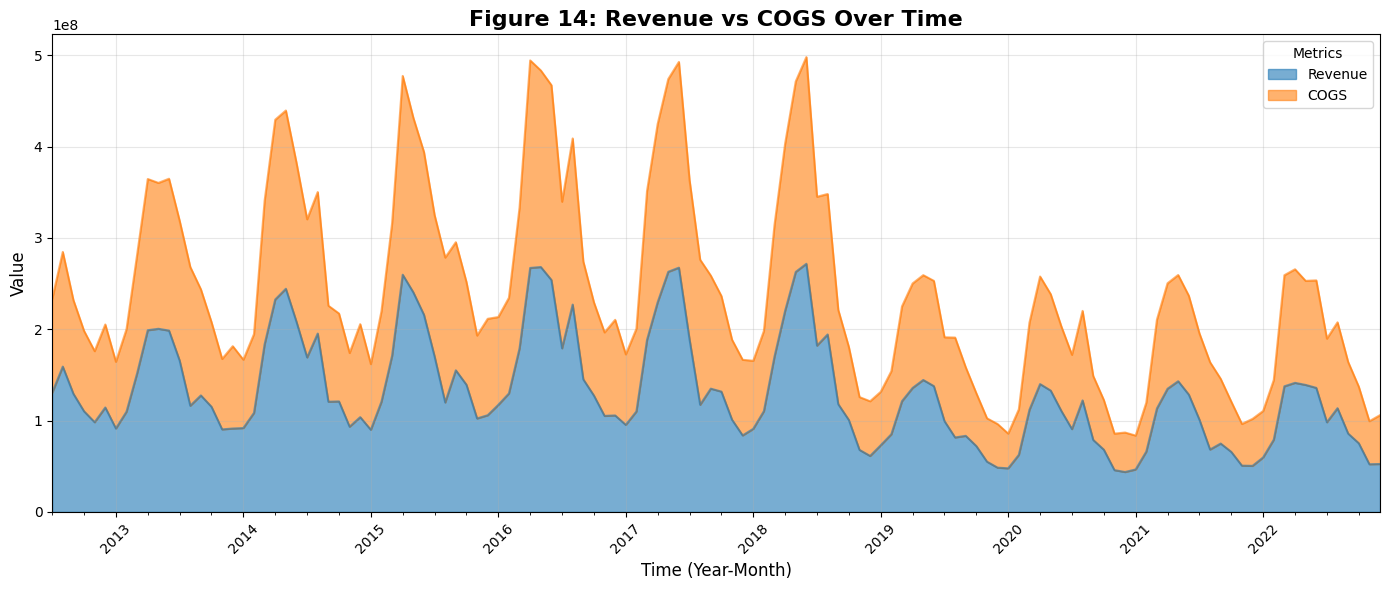

In [ ]:
sales_df = dfs['sales'].copy()
sales_df['Date'] = pd.to_datetime(sales_df['Date'])
sales_df['YearMonth'] = sales_df['Date'].dt.to_period('M')

monthly = sales_df.groupby('YearMonth')[['Revenue','COGS']].sum()

monthly.plot.area(figsize=(14,6), alpha=0.6)

# Tiêu đề
plt.title("Figure 14: Revenue vs COGS Over Time", fontsize=16, fontweight='bold')

# Nhãn trục
plt.xlabel("Time (Year-Month)", fontsize=12)
plt.ylabel("Value", fontsize=12)

# Xoay trục X
plt.xticks(rotation=45)

# Legend
plt.legend(title="Metrics")

# Grid
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**MÔ TẢ:**
- Sự đồng pha rõ rệt của Revenue và COGS thể hiện mô hình kinh doanh có cấu trúc chi phí ổn định, luôn duy trì lợi nhuận dương. Đồng thời, không có dấu hiệu tăng giảm bất tưởng của COGS so với Revenue, thể hiện sự kiểm soát chi phí tốt. Từ năm 2019, cả Revenue và COGS đều giảm, biên độ không đổi nhưng quy mô nhỏ lại. Như vậy, vấn đề năm ở việc **doanh thu giảm, không phải do kiểm soát chi phí kém**.
- Tính thời vụ vẫn được thể hiện rất rõ. Kết hợp với Figure 3, 4, 5, ta có thể thấy tính thời vụ phụ thuộc vào thị phần quá lớn của Streetwear. GenZ và Casual là hai danh mục sản phẩm mang ít tính thời vụ hơn, nếu có thể mở rộng thị phần ở hai mảng này sẽ tạo ra doanh thu lớn hơn cho doanh nghiệp.

**KẾT LUẬN:**
1. Quản trị tồn kho chủ động: Vì COGS biến động rất mạnh theo mùa, doanh nghiệp cần sử dụng dữ liệu này để dự báo lượng hàng nhập chính xác cho các đỉnh cuối năm, tránh việc tồn kho cao sau khi mùa cao điểm kết thúc.
2. Cần "san phẳng" doanh thu: Để giảm bớt rủi ro phụ thuộc vào mùa vụ, doanh nghiệp nên phát triển thêm các dòng sản phẩm ít tính thời vụ là Casual & GenZ để lấp đầy các khoảng "thung lũng".
3. Tối ưu hóa COGS & Marketing: Trong các đợt cao điểm, lượng hàng bán ra lớn là cơ hội để đàm phán giá tốt hơn với nhà cung cấp nhằm nới rộng khoảng cách giữa đường Revenue và COGS, tối đa hóa lợi nhuận. Đồng thời, đó cũng là thời điểm vàng cho việc thực hiện các chiến dịch Marketing tập trung.
4. Chúng tôi sẽ đồng thời model hóa seasonality nhằm dự báo dễ hơn cho doanh nghiệp trong tình huống volatility cao như hiện tại.






### Key takeaway: BCG Matrix

Ma trận BCG là một công cụ phân tích chiến lược giúp doanh nghiệp đánh giá danh mục sản phẩm của mình dựa trên hai chiều: **Tốc độ tăng trưởng thị trường (Market Growth Rate)** và **Thị phần tương đối (Relative Market Share)**. Từ đó, các sản phẩm được phân loại thành 4 nhóm chính, mỗi nhóm có hàm ý chiến lược khác nhau:

-   **Stars (Ngôi sao)**: Tăng trưởng cao, thị phần cao. Cần đầu tư để duy trì tăng trưởng, có tiềm năng trở thành Cash Cows.
-   **Cash Cows (Bò sữa)**: Tăng trưởng thấp, thị phần cao. Tạo ra lượng tiền mặt lớn nhưng không cần nhiều đầu tư. Nên "vắt sữa" để tài trợ cho các Stars và Question Marks.
-   **Question Marks (Dấu hỏi)**: Tăng trưởng cao, thị phần thấp. Tiềm năng lớn nhưng rủi ro cao, cần cân nhắc đầu tư mạnh để biến thành Stars hoặc rút lui.
-   **Dogs (Chó mực)**: Tăng trưởng thấp, thị phần thấp. Thường tạo ra ít tiền mặt hoặc thậm chí thua lỗ. Nên cân nhắc loại bỏ.


Dựa vào toàn bộ insights đã được nêu ra, chúng tôi đưa đến kết luận là **KHUYẾN NGHỊ PHÁT TRIỂN DANH MỤC SẢN PHẨM** theo BCG Matrix dưới đây:

Figure 14: BCG Matrix Classification


,category,growth,relative_market_share,BCG_Segment
0,Streetwear,5.62,1.000000,Cash Cow
1,Outdoor,-4.37,0.189680,Dog
2,Casual,16.43,0.034910,Question Mark
3,GenZ,11.69,0.026258,Question Mark


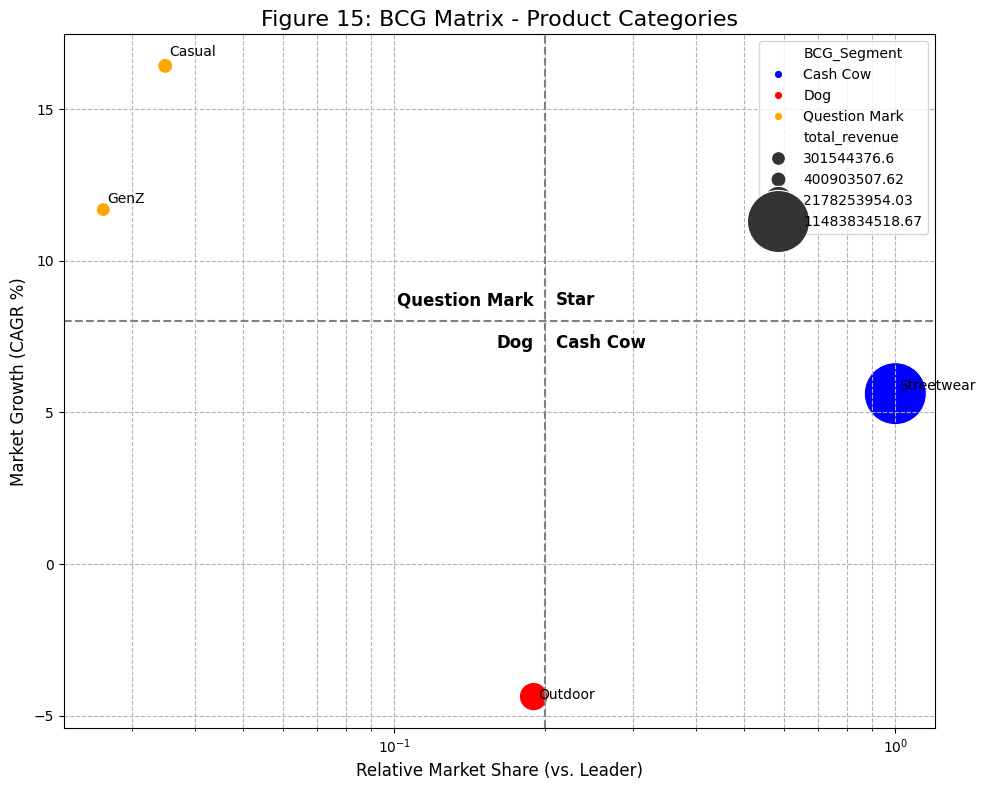

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data from category_report (which contains CAGR and total_revenue)
bcg_data = category_report.copy()

# Rename 'index' column (category name) to 'category' for consistency
bcg_data = bcg_data.rename_axis('category').reset_index()

# Calculate Relative Market Share
# Assuming 'Streetwear' is the market leader for relative market share calculation.
# Max revenue will be used to normalize other categories.
max_revenue_category = bcg_data.loc[bcg_data['total_revenue'].idxmax(), 'total_revenue']

bcg_data['relative_market_share'] = bcg_data['total_revenue'] / max_revenue_category

# Adjust CAGR to be just 'growth' for plotting simplicity (and in percentage)
bcg_data['growth'] = bcg_data['cagr_%']

# Define thresholds based on previous analysis and desired insights
# For growth: GenZ (11.69%), Casual (16.43%) should be High Growth.
# Streetwear (5.62%), Outdoor (-4.37%) should be Low Growth.
# So, a threshold around 8% would work.
growth_threshold = 8.0 # Example: 8% CAGR

# For market share: Streetwear (0.80) should be High Share.
# Outdoor (0.15), Casual (0.028), GenZ (0.02) should be Low Share.
# So, a threshold around 0.2 would work.
share_threshold = 0.2 # Example: 20% of the leader's market share

# Classify into BCG Matrix
def classify_bcg(row):
    if row['growth'] >= growth_threshold and row['relative_market_share'] >= share_threshold:
        return 'Star'
    elif row['growth'] < growth_threshold and row['relative_market_share'] >= share_threshold:
        return 'Cash Cow'
    elif row['growth'] >= growth_threshold and row['relative_market_share'] < share_threshold:
        return 'Question Mark'
    else:
        return 'Dog'

bcg_data['BCG_Segment'] = bcg_data.apply(classify_bcg, axis=1)

# Display the BCG table
print("Figure 14: BCG Matrix Classification")
display(bcg_data[['category', 'growth', 'relative_market_share', 'BCG_Segment']])

# --- Plotting the BCG Matrix ---
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=bcg_data,
    x='relative_market_share',
    y='growth',
    hue='BCG_Segment',
    size='total_revenue',
    sizes=(100, 2000), # Adjust marker size based on total_revenue
    palette={'Star': 'green', 'Cash Cow': 'blue', 'Question Mark': 'orange', 'Dog': 'red'},
    legend='full'
)

# Add thresholds lines
plt.axvline(x=share_threshold, color='grey', linestyle='--', linewidth=1.5)
plt.axhline(y=growth_threshold, color='grey', linestyle='--', linewidth=1.5)

# Annotate points with category names
for i, row in bcg_data.iterrows():
    plt.text(row['relative_market_share'] * 1.02, row['growth'] * 1.02, row['category'], fontsize=10)

# Add labels for quadrants
plt.text(share_threshold * 0.95, growth_threshold * 1.05, 'Question Mark', ha='right', va='bottom', fontsize=12, color='black', weight='bold')
plt.text(share_threshold * 1.05, growth_threshold * 1.05, 'Star', ha='left', va='bottom', fontsize=12, color='black', weight='bold')
plt.text(share_threshold * 0.95, growth_threshold * 0.95, 'Dog', ha='right', va='top', fontsize=12, color='black', weight='bold')
plt.text(share_threshold * 1.05, growth_threshold * 0.95, 'Cash Cow', ha='left', va='top', fontsize=12, color='black', weight='bold')

plt.title('Figure 15: BCG Matrix - Product Categories', fontsize=16)
plt.xlabel('Relative Market Share (vs. Leader)', fontsize=12)
plt.ylabel('Market Growth (CAGR %)', fontsize=12)
plt.xscale('log') # Often log scale for market share in BCG
plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout()
plt.show()


**KIỂM CHỨNG VÀ KẾT LUẬN:**

Ma trận BCG với các ngưỡng đã điều chỉnh cho thấy:

-   **Streetwear (Cash Cow)**: Có thị phần tương đối cao (gần 80%) nhưng tốc độ tăng trưởng chỉ ở mức trung bình (5.62%), thấp hơn ngưỡng tăng trưởng thị trường. Điều này xác nhận Streetwear là "bò sữa" tạo ra doanh thu ổn định nhưng không còn là động lực tăng trưởng chính. Đây là kết quả phù hợp với nhận định rằng Streetwear từng là "Stars" nhưng đang chuyển sang giai đoạn "Cash Cow", và doanh nghiệp nên giảm phụ thuộc vào nó.

-   **Outdoor (Dog)**: Có thị phần tương đối thấp (15%) và tăng trưởng âm (-4.37%), thấp hơn cả hai ngưỡng. Điều này khẳng định Outdoor là một "Dog", không tạo ra giá trị đáng kể và có thể cân nhắc loại bỏ hoặc giảm thiểu đầu tư để tối ưu hóa nguồn lực.

-   **Casual (Question Mark)**: Mặc dù có thị phần tương đối thấp (2.8%), Casual lại có tốc độ tăng trưởng rất cao (16.43%), vượt xa ngưỡng tăng trưởng thị trường. Điều này xếp Casual vào nhóm "Question Mark", cho thấy tiềm năng lớn nhưng cần đầu tư mạnh để phát triển thị phần và chuyển đổi thành "Stars".

-   **GenZ (Question Mark)**: Tương tự Casual, GenZ cũng có thị phần tương đối thấp (2%) nhưng tốc độ tăng trưởng cao (11.69%), đặt nó vào nhóm "Question Mark". GenZ cũng là một danh mục đáng để đầu tư và phát triển để khai thác tiềm năng thị trường.

Những phân loại này phù hợp với các kết luận và giả thuyết đã đưa ra trước đó trong phân tích về danh mục sản phẩm, đồng thời củng cố chiến lược đề xuất: chuyển dịch trọng tâm từ Streetwear sang đầu tư vào Casual và GenZ, trong khi cân nhắc rút lui khỏi Outdoor.

### Bonus: Products to discard (Dogs) and Products to promote (Stars/Cash Cows)

In [ ]:
import pandas as pd
import numpy as np

# Retrieve necessary DataFrames from the global 'dfs' dictionary
inventory_df = dfs['inventory']
products_df = dfs['products']
orders_df = dfs['orders']
order_items_df = dfs['order_items']

# --- Prepare inventory data ---
inventory_df['snapshot_date'] = pd.to_datetime(inventory_df['snapshot_date'])

# Merge inventory_df with products_df. Since both have 'product_name' and 'category',
# we need to handle suffixes. Assume 'inventory_df' contains the desired product info.
master_inv_merged = inventory_df.merge(
    products_df,
    on='product_id',
    how='left',
    suffixes=('_inv', '_prod') # Add specific suffixes to differentiate
)

# Rename the desired product_name and category columns to their original names
# We'll use the ones from inventory_df (which will have _inv suffix)
if 'product_name_inv' in master_inv_merged.columns:
    master_inv_merged = master_inv_merged.rename(columns={'product_name_inv': 'product_name'})
if 'category_inv' in master_inv_merged.columns:
    master_inv_merged = master_inv_merged.rename(columns={'category_inv': 'category'})

# Drop the duplicate columns from products_df (which will have _prod suffix)
master_inv = master_inv_merged.drop(columns=[col for col in master_inv_merged.columns if '_prod' in str(col)], errors='ignore')

latest_month = master_inv['snapshot_date'].max()
latest_inv   = master_inv[master_inv['snapshot_date'] == latest_month].copy()

# Calculate inventory value for the latest snapshot
latest_inv['inventory_value']   = latest_inv['stock_on_hand'] * latest_inv['cogs']

# --- Prepare sales data to get actual net revenue per product ---
df_product_sales = order_items_df.merge(
    products_df[['product_id', 'product_name', 'category']],
    on='product_id',
    how='left'
).merge(
    orders_df[['order_id', 'order_date']],
    on='order_id',
    how='left'
)
df_product_sales['order_date'] = pd.to_datetime(df_product_sales['order_date'])
df_product_sales['net_revenue'] = (df_product_sales['quantity'] * df_product_sales['unit_price']) - df_product_sales['discount_amount']

# Aggregate net revenue per product
product_net_revenue = df_product_sales.groupby('product_id')['net_revenue'].sum().reset_index()

# --- Identify products to discard: Overstocked AND Low Net Revenue ---
# Filter for overstocked products from latest_inv
overstocked_products = latest_inv[latest_inv['overstock_flag'] == 1].copy()

# Merge overstocked products with their total net revenue
products_to_discard = overstocked_products.merge(
    product_net_revenue,
    on='product_id',
    how='left'
)

# Fill NaN net_revenue with 0 for products that might be overstocked but never sold
products_to_discard['net_revenue'] = products_to_discard['net_revenue'].fillna(0)

# Sort by net_revenue (ascending) and then by inventory_value (descending) for tie-breaking
products_to_discard = products_to_discard.sort_values(
    by=['net_revenue', 'inventory_value'],
    ascending=[True, False]
)

print('Figure 40: Top 20 Products to Discard (Overstocked & Lowest Net Revenue)')
display(products_to_discard[['product_name', 'category', 'net_revenue', 'inventory_value', 'stock_on_hand']].head(20))

Figure 40: Top 20 Products to Discard (Overstocked & Lowest Net Revenue)


,product_name,category,net_revenue,inventory_value,stock_on_hand
208,NamStyle YY-12,GenZ,57985.78,10883.703726,6
9,DragonWear RS-03,Outdoor,65770.19,23348.409084,6
18,DragonWear YY-01,GenZ,70486.50,51656.535000,9
327,VietMotion UC-26,Streetwear,95527.43,55588.680000,6
213,SaigonCore MA-02,Casual,101908.77,95728.356360,12
5,DragonWear MA-29,Casual,140831.42,53811.135000,9
223,SaigonCore YY-38,GenZ,154024.25,9584.846735,9
202,VietMode RS-04,Outdoor,203300.75,42612.337897,21
34,LotusWear UC-01,Streetwear,230283.88,68211.045000,6
220,SaigonCore YY-23,GenZ,306082.67,15586.745038,5


In [ ]:
cash_cow_categories = ['Streetwear']
question_mark_categories = ['Casual', 'GenZ']

# Combine these categories for "potential Star / Cash Cow" products
star_cash_cow_categories = cash_cow_categories + question_mark_categories

# Filter df_product_sales for these categories
top_products_df = df_product_sales[df_product_sales['category'].isin(star_cash_cow_categories)].copy()

# Calculate total net revenue for each product
top_products_summary = top_products_df.groupby(['product_id', 'product_name', 'category'])['net_revenue'].sum().reset_index()

# Sort by net_revenue and get the top 20
top_20_star_cash_cow_products = top_products_summary.sort_values(by='net_revenue', ascending=False).head(20)

print('Figure 41: Top 20 Potential Star / Cash Cow Products (by Net Revenue)')
display(top_20_star_cash_cow_products.drop(columns=['product_id']))

Figure 41: Top 20 Potential Star / Cash Cow Products (by Net Revenue)


,product_name,category,net_revenue
284,SaigonFlex UM-92,Streetwear,3.804687e+08
469,HanoiStreet UM-10,Streetwear,3.275091e+08
248,SaigonFlex UM-43,Streetwear,3.250149e+08
274,SaigonFlex UM-80,Streetwear,2.565521e+08
288,SaigonFlex UM-96,Streetwear,2.410001e+08
386,SaigonFlex UC-69,Streetwear,1.989966e+08
303,SaigonFlex UM-11,Streetwear,1.924103e+08
927,UrbanVN UE-05,Streetwear,1.770363e+08
255,SaigonFlex UM-54,Streetwear,1.758413e+08
210,SaigonFlex UM-01,Streetwear,1.712015e+08


## **2.2. Customer**
Bên cạnh vấn đề của mảng Sản phẩm, Sales & Marketing cũng là một điểm chạm quan trọng khi doanh nghiệp trực tiếp tiếp xúc với khách hàng qua các khía cạnh như promotion, thanh toán, CRM,...

### **Promotion**

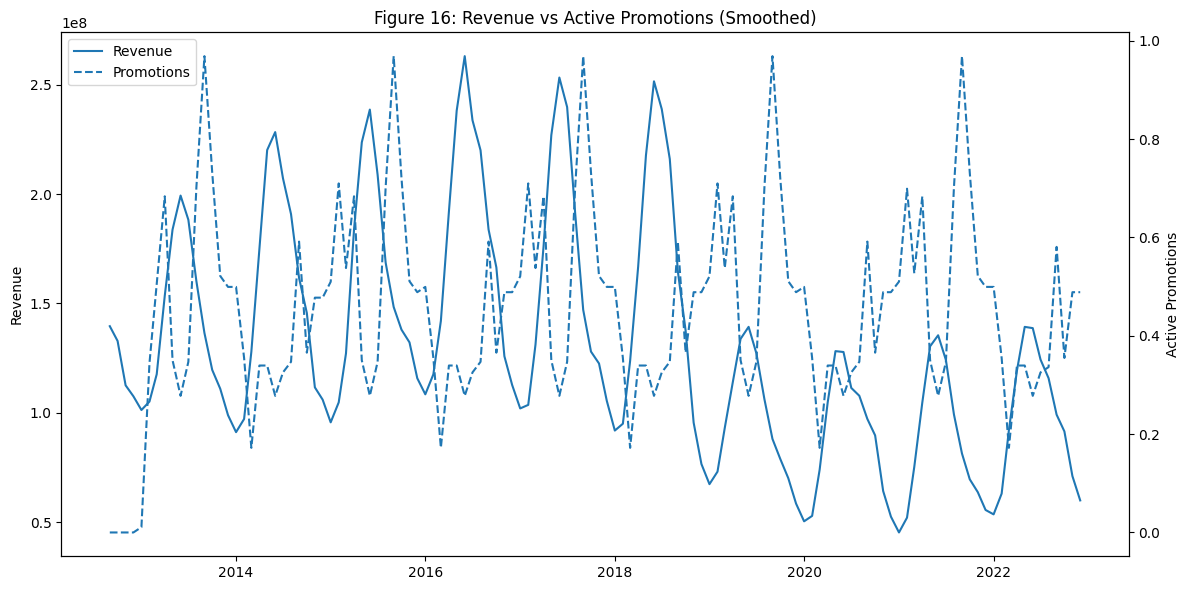

In [ ]:
# 1. PROCESS SALES

sales['Date'] = pd.to_datetime(sales['Date'])
sales['year'] = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.month

monthly_revenue = sales.groupby(['year', 'month'])['Revenue'].sum().reset_index()


# 2. PROCESS PROMOTION

promotions['start_date'] = pd.to_datetime(promotions['start_date'])
promotions['end_date'] = pd.to_datetime(promotions['end_date'])

date_range = pd.date_range(sales['Date'].min(), sales['Date'].max())

promo_counts = []
for d in date_range:
  count = ((promotions['start_date'] <= d) & (promotions['end_date'] >= d)).sum()
  promo_counts.append(count)

promo_df = pd.DataFrame({'date': date_range, 'promo_count': promo_counts})
promo_df['year'] = promo_df['date'].dt.year
promo_df['month'] = promo_df['date'].dt.month

monthly_promo = promo_df.groupby(['year', 'month'])['promo_count'].mean().reset_index()


# 3. MERGE

merged = pd.merge(monthly_revenue, monthly_promo, on=['year', 'month'])
merged['time'] = pd.to_datetime(merged['year'].astype(str) + '-' + merged['month'].astype(str))


# 4. SMOOTH

merged['Revenue_smooth'] = merged['Revenue'].rolling(3).mean()
merged['Promo_smooth'] = merged['promo_count'].rolling(3).mean()


# 5. PLOT (MÀU RÕ RÀNG)

fig, ax1 = plt.subplots(figsize=(12,6))

# Revenue → xanh dương
ax1.plot(merged['time'], merged['Revenue_smooth'], label='Revenue')
ax1.set_ylabel('Revenue')

# Promotion → đỏ
ax2 = ax1.twinx()
ax2.plot(merged['time'], merged['Promo_smooth'], linestyle='--', label='Promotions')
ax2.set_ylabel('Active Promotions')

# Title + format
plt.title('Figure 16: Revenue vs Active Promotions (Smoothed)')
plt.xticks(rotation=45)

# Legend (gộp 2 trục)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.tight_layout()
plt.show()

**MÔ TẢ**: Tương quan giữa Doanh thu và các kỳ giảm giá:
- Promotion không đồng pha với Revenue, nhiều đoạn promo tăng mạnh nhưng Revenue không tăng tương ứng thậm chí giảm. Điều này thể hiện sự thất bại của Promotion trong việc kích cầu doanh thu.
- Promotion chạy ngược mùa: Doanh thu  đạt đỉnh vào giữa năm nhưng promotion lại rải rác, không tập trung đúng thời điểm peak. Campaign chưa được tối ưu theo mùa vụ
- Correlation yếu (thậm chí có lúc âm), thể hiện hiệu quả marketing có thể thấp hoặc sai timing.
- Trend dài hạn: doanh thu giảm nhưng promotion không tăng tương ứng, nghĩa là doanh nghiệp đã chưa sử dụng promotion như một công cụ để chống suy giảm nhu cầu khách hàng.

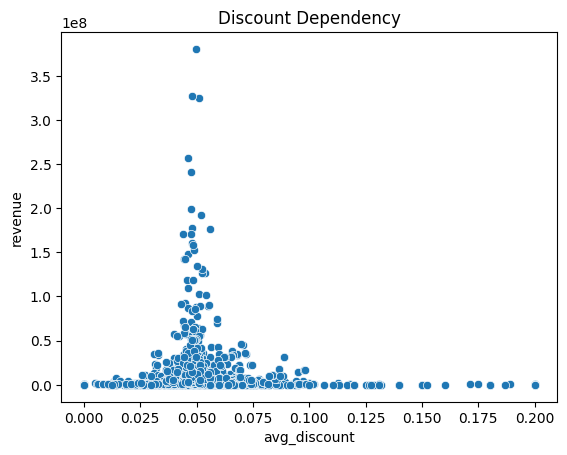

In [ ]:
df = df_product_sales.copy()

df['gross_sales'] = df['quantity'] * df['unit_price']

#DISCOUNT DEPENDENCY
df['discount_pct'] = (
    df.discount_amount /
    df.gross_sales
).fillna(0)

discount_dep = (
    df.groupby('product_id')
    .agg(
        revenue=('net_revenue', 'sum'),
        avg_discount=('discount_pct', 'mean')
    )
)

sns.scatterplot(
    data=discount_dep,
    x='avg_discount',
    y='revenue'
)
plt.title('Figure 17: Discount Dependency')
plt.show()

**MÔ TẢ**: Mức độ doanh thu phụ thuộc vào giảm giá. Doanh thu cao tập trung ở xung quanh một mức giảm giá nhất định (5%), trong khi các chiến dịch giảm giá sâu >10% gần như không tạo ra doanh thu. Như vậy:
- Các sản phẩm bán chạy nhất không cần giảm giá nhiều.
- Việc giảm giá mạnh không cứu được các mã sản phẩm yếu.
=> Doanh thu được tạo ra bởi sự phù hợp của sản phẩm (product-market fit) chứ không phải giảm giá. Nói cách khác, doanh nghiệp đang sử dụng Promotion sai cách.


**KHUYẾN NGHỊ:**

1. Ngừng giảm giá đại trà cho toàn bộ sản phẩm. Loại bỏ discount trên các sản phẩm có doanh thu thấp để giữ lại marginal profit và tránh đốt tiền vô ích.
2. Chuyển đổi giảm giá:
- Tập trung giảm giá (khoảng 5%) vào top 20% sản phẩm có doanh thu cao nhất để tối đa hóa doanh thu và tăng traffics.
- Dồn ngân sách giảm giá vào mùa đỉnh (tháng 4-6) và cắt ở các off-season để tránh lãng phí.
3. Chuyển đổi sang các cách kích cầu doanh thu khác như: tăng cường quan hệ khách hàng (CRM) và brand loyalty, kích cầu qua tối ưu phương thức thanh toán,... sẽ được trình bày bên dưới.


### **Payment methods**

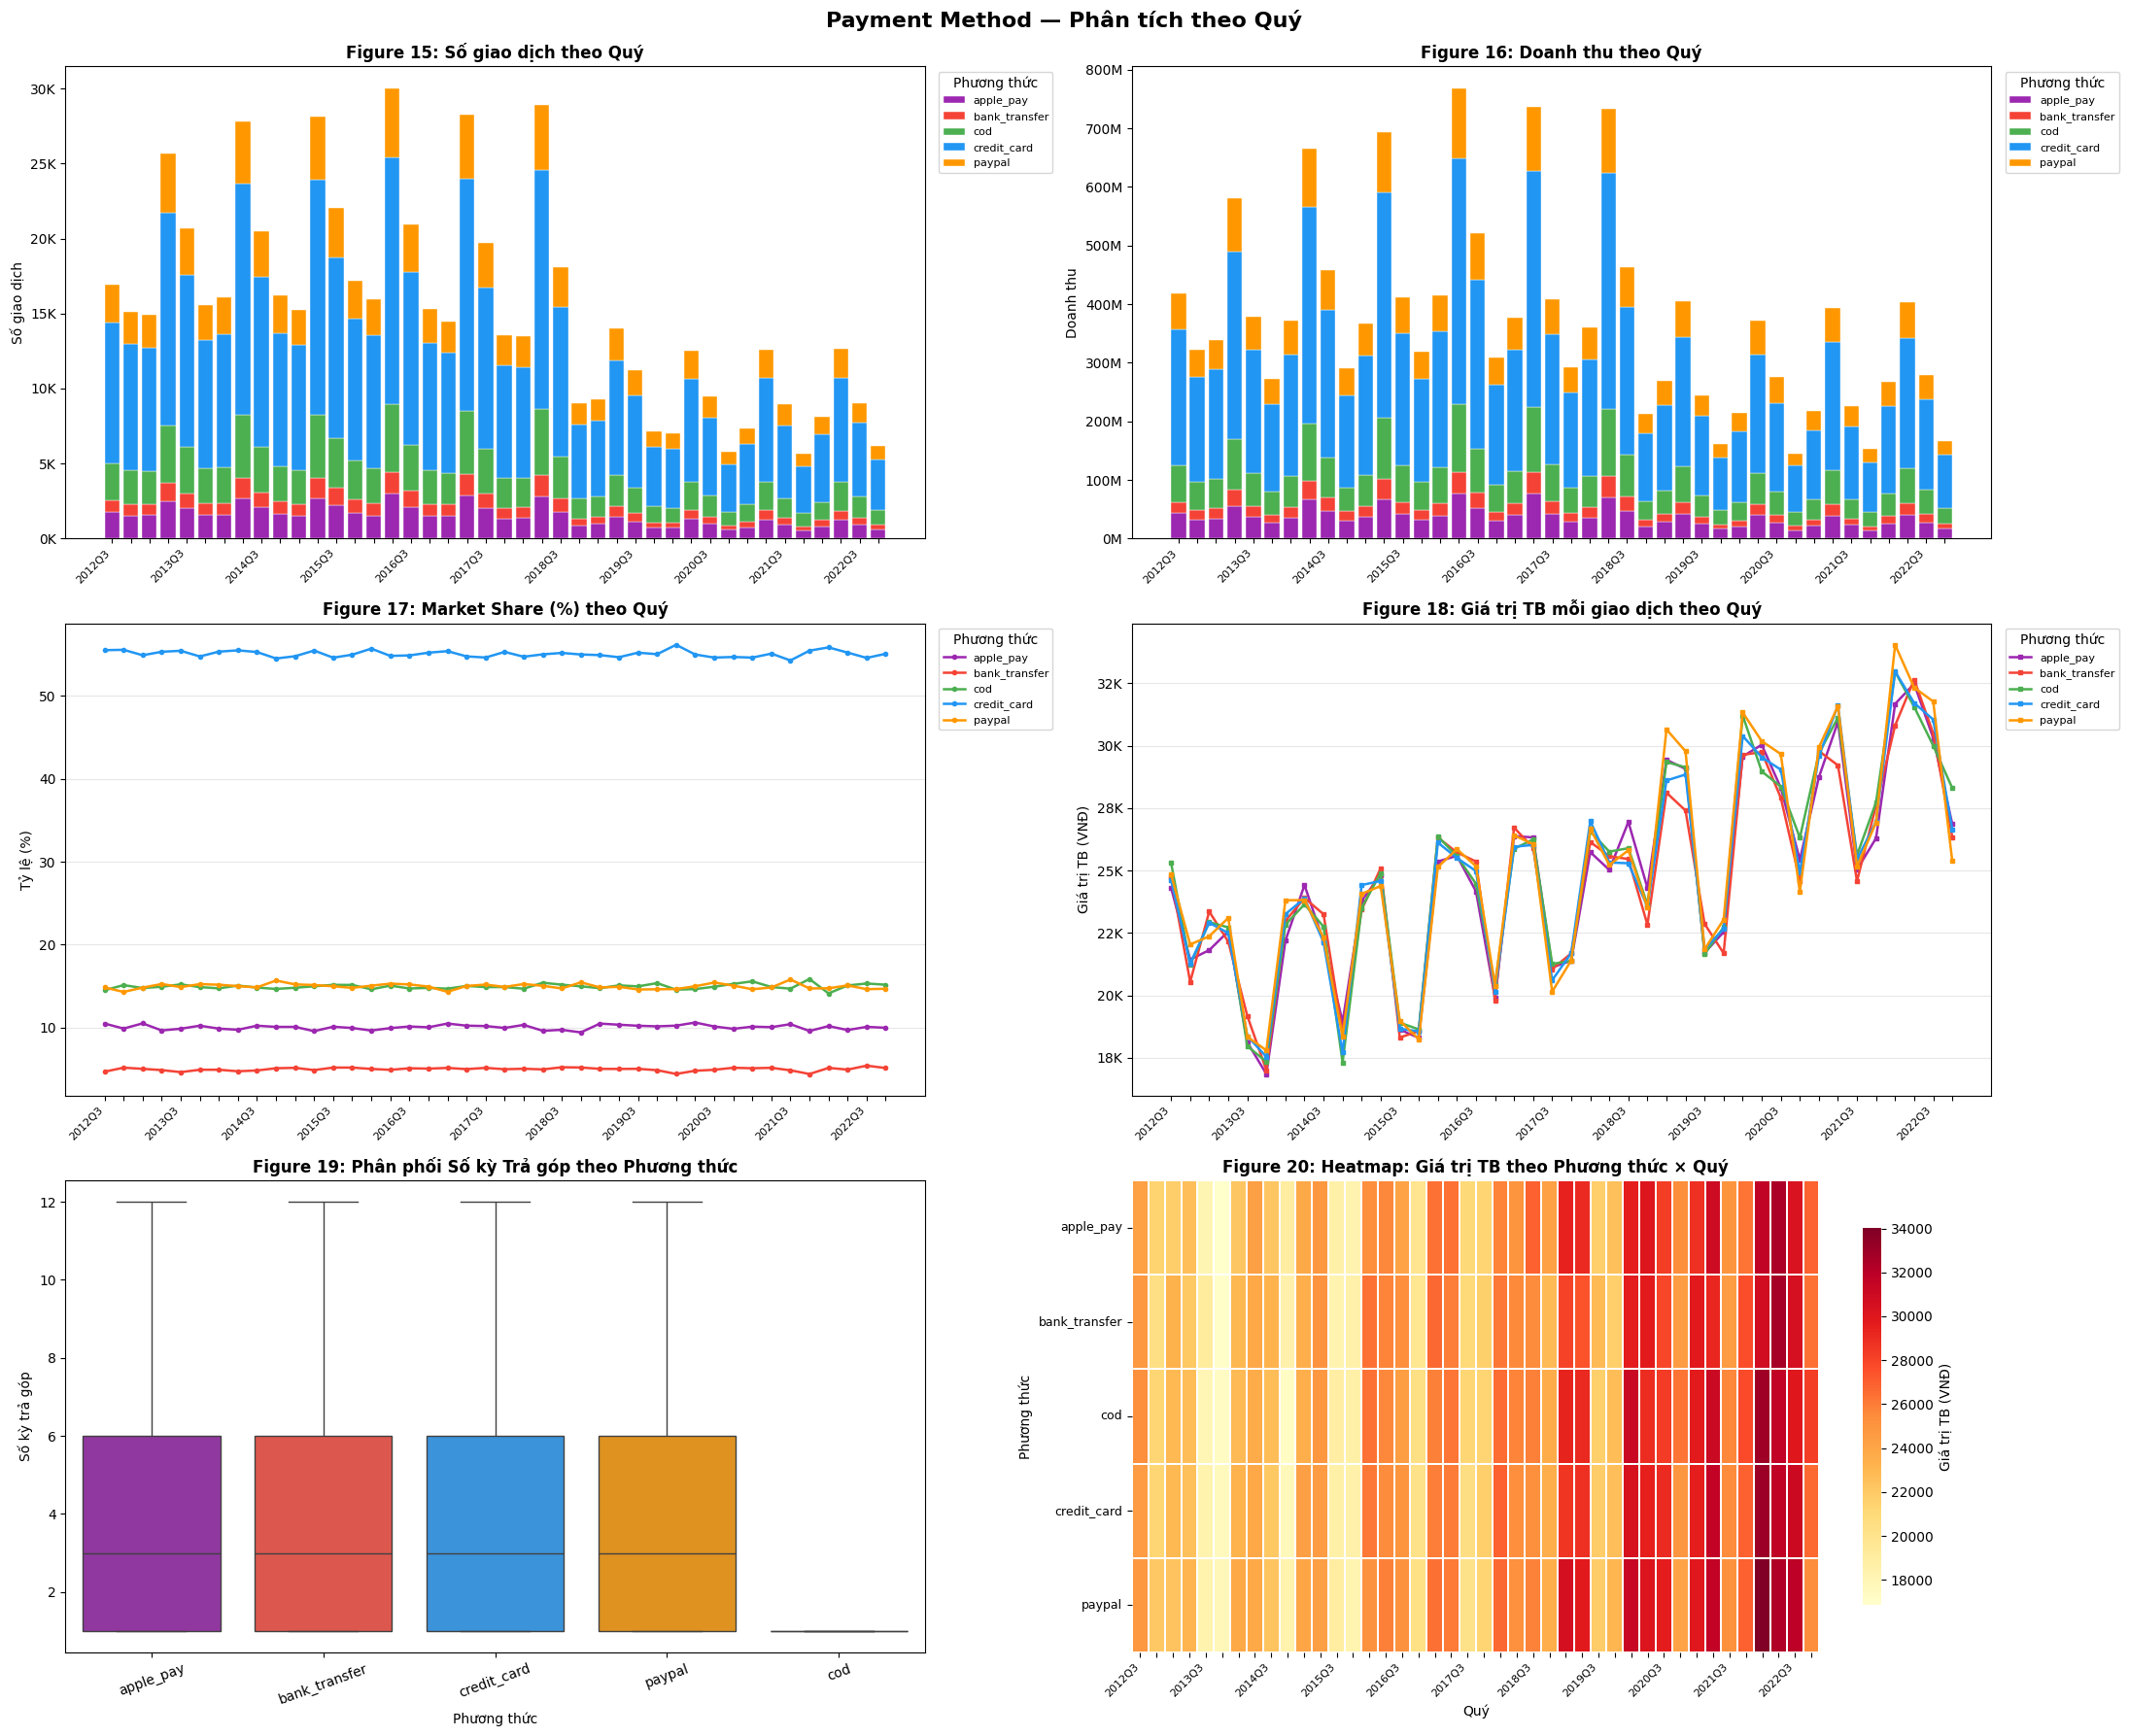

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── 0. CHUẨN BỊ DATA ──────────────────────────────────────────────
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['quarter'] = orders['order_date'].dt.to_period('Q')

df = payments.merge(orders[['order_id', 'order_date', 'quarter']], on='order_id', how='left')

METHODS = df['payment_method'].value_counts().index.tolist()
COLORS  = {'credit_card': '#2196F3', 'paypal': '#FF9800',
           'cod': '#4CAF50', 'apple_pay': '#9C27B0', 'bank_transfer': '#F44336'}

# Helper: chỉ show nhãn mỗi N quý
def sparse_xticks(ax, labels, every=4):
    ticks = range(len(labels))
    ax.set_xticks(list(ticks))
    ax.set_xticklabels(
        [str(l) if i % every == 0 else '' for i, l in enumerate(labels)],
        rotation=45, ha='right', fontsize=8
    )

# ── 1. VẼ ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 18))
fig.suptitle('Payment Method — Phân tích theo Quý', fontsize=16, fontweight='bold', y=0.99)

# ── 1A. Số lượng giao dịch theo quý (stacked bar) ─────────────────
ax1 = fig.add_subplot(3, 2, 1)
txn_q = df.groupby(['quarter', 'payment_method']).size().unstack(fill_value=0)
labels_q = [str(q) for q in txn_q.index]
txn_q_vals = txn_q.values
bottom = None
for i, method in enumerate(txn_q.columns):
    vals = txn_q_vals[:, i]
    ax1.bar(range(len(labels_q)), vals, bottom=bottom,
            label=method, color=COLORS.get(method, '#999'), edgecolor='white', linewidth=0.3)
    bottom = vals if bottom is None else bottom + vals
ax1.set_title('Figure 15: Số giao dịch theo Quý', fontweight='bold')
ax1.set_ylabel('Số giao dịch')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
sparse_xticks(ax1, labels_q, every=4)
ax1.legend(title='Phương thức', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

# ── 1B. Doanh thu theo quý (stacked bar) ──────────────────────────
ax2 = fig.add_subplot(3, 2, 2)
rev_q = df.groupby(['quarter', 'payment_method'])['payment_value'].sum().unstack(fill_value=0)
rev_vals = rev_q.values
bottom = None
for i, method in enumerate(rev_q.columns):
    vals = rev_vals[:, i]
    ax2.bar(range(len(labels_q)), vals, bottom=bottom,
            label=method, color=COLORS.get(method, '#999'), edgecolor='white', linewidth=0.3)
    bottom = vals if bottom is None else bottom + vals
ax2.set_title('Figure 16: Doanh thu theo Quý', fontweight='bold')
ax2.set_ylabel('Doanh thu')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
sparse_xticks(ax2, labels_q, every=4)
ax2.legend(title='Phương thức', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

# ── 1C. Market share (%) theo quý ─────────────────────────────────
ax3 = fig.add_subplot(3, 2, 3)
share_q = txn_q.div(txn_q.sum(axis=1), axis=0) * 100
x_pos = range(len(labels_q))
for method in share_q.columns:
    ax3.plot(x_pos, share_q[method],
             marker='o', markersize=3, label=method,
             color=COLORS.get(method, '#999'), linewidth=1.8)
ax3.set_title('Figure 17: Market Share (%) theo Quý', fontweight='bold')
ax3.set_ylabel('Tỷ lệ (%)')
sparse_xticks(ax3, labels_q, every=4)
ax3.legend(title='Phương thức', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax3.grid(axis='y', alpha=0.3)

# ── 1D. Giá trị TB mỗi giao dịch theo quý ────────────────────────
ax4 = fig.add_subplot(3, 2, 4)
avg_q = df.groupby(['quarter', 'payment_method'])['payment_value'].mean().unstack(fill_value=0)
for method in avg_q.columns:
    ax4.plot(x_pos, avg_q[method],
             marker='s', markersize=3, label=method,
             color=COLORS.get(method, '#999'), linewidth=1.8)
ax4.set_title('Figure 18: Giá trị TB mỗi giao dịch theo Quý', fontweight='bold')
ax4.set_ylabel('Giá trị TB (VNĐ)')
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
sparse_xticks(ax4, labels_q, every=4)
ax4.legend(title='Phương thức', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax4.grid(axis='y', alpha=0.3)

# ── 1E. Boxplot installments ──────────────────────────────────────
ax5 = fig.add_subplot(3, 2, 5)
df_inst = df[df['installments'] > 0]
order_by_median = (df_inst.groupby('payment_method')['installments']
                   .median().sort_values(ascending=False).index)
sns.boxplot(data=df_inst, x='payment_method', y='installments',
            order=order_by_median, ax=ax5,
            palette=[COLORS.get(m, '#999') for m in order_by_median])
ax5.set_title('Figure 19: Phân phối Số kỳ Trả góp theo Phương thức', fontweight='bold')
ax5.set_xlabel('Phương thức')
ax5.set_ylabel('Số kỳ trả góp')
ax5.tick_params(axis='x', rotation=20)

# ── 1F. Heatmap gọn hơn: chỉ show nhãn năm, bỏ Q ─────────────────
ax6 = fig.add_subplot(3, 2, 6)
heat_data = df.groupby(['payment_method', 'quarter'])['payment_value'].mean().unstack()
heat_data.columns = heat_data.columns.astype(str)

# Chỉ hiển thị nhãn mỗi 4 quý (mỗi năm 1 nhãn)
n_cols = len(heat_data.columns)
xtick_labels = [col if i % 4 == 0 else '' for i, col in enumerate(heat_data.columns)]

sns.heatmap(heat_data, annot=False, cmap='YlOrRd',   # tắt annot để thoáng
            ax=ax6, cbar_kws={'label': 'Giá trị TB (VNĐ)', 'shrink': 0.8},
            linewidths=0.2, linecolor='white')
ax6.set_title('Figure 20: Heatmap: Giá trị TB theo Phương thức × Quý', fontweight='bold')
ax6.set_xlabel('Quý')
ax6.set_ylabel('Phương thức')
ax6.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=8)
ax6.set_yticklabels(ax6.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

**Fig 15 & 16 — Số giao dịch & Doanh thu theo Quý**

Credit card là xương sống của toàn bộ hệ thống thanh toán, chiếm ~50–55% cả giao dịch lẫn doanh thu xuyên suốt 10 năm mà không có dấu hiệu suy giảm. Đây không đơn thuần là phương thức phổ biến nhất — mà là điểm tập trung rủi ro lớn nhất: bất kỳ downtime, friction hay lỗi trong luồng credit card đều ảnh hưởng trực tiếp đến hơn nửa doanh thu toàn sàn ngay lập tức.

Business có tính mùa vụ rõ rệt và nhất quán — đỉnh giao dịch xuất hiện đều đặn vào Q3 hàng năm, nhiều khả năng gắn với các campaign lớn hoặc mùa mua sắm. Tuy nhiên đỉnh tăng trưởng đạt cực đại vào 2016–2018 rồi giảm dần, phản ánh business đã qua giai đoạn tăng trưởng nóng và đang bước vào phase bão hòa từ 2019 trở đi.

PayPal (gần 15%) giữ vị trí #2 ổn định nhưng không có xu hướng tăng rõ ràng — đây là nhóm khách hàng trung thành về thói quen thanh toán nhưng không được kích hoạt để mua thêm hay mua thường xuyên hơn, tiềm năng còn bỏ ngỏ.
COD gần như biến mất sau 2019–2020 do hai lực cộng hưởng: thị trường dần trưởng thành khiến khách tin tưởng thanh toán online hơn, và COVID-19 là cú hích quyết định — lo ngại lây nhiễm qua tiền mặt và hạn chế tiếp xúc trực tiếp đẩy khách hàng chủ động từ bỏ COD nhanh hơn bất kỳ chiến dịch nào có thể làm được. Đây là thay đổi hành vi có tính cấu trúc — COD khó phục hồi về mức cũ ngay cả khi dịch kết thúc hoàn toàn.


**Fig 17 — Market Share (%) theo Quý**

Market share của cả 5 phương thức gần như phẳng hoàn toàn trong suốt 10 năm — **không có phương thức nào đang ăn thị phần của phương thức khác, kể cả trong giai đoạn fintech và mobile payment bùng nổ mạnh mẽ toàn cầu 2015–2020. Điều này là tín hiệu đáng lo: platform đang để khách hàng tự chọn phương thức theo thói quen cũ thay vì chủ động định hướng hành vi thanh toán về các phương thức có chi phí vận hành thấp hơn hoặc conversion rate cao hơn.

Apple Pay (~10%) không tăng market share dù đây là giai đoạn bùng nổ của ví điện tử và thanh toán di động toàn cầu — cho thấy user base của platform không phải mobile-first, hoặc quan trọng hơn là checkout flow trên mobile chưa đủ mượt và thuận tiện để thay đổi thói quen người dùng.

Bank transfer (~5%) là phương thức thấp nhất và hoàn toàn flat trong 10 năm — không có bất kỳ tín hiệu tăng trưởng nào, chi phí vận hành cao, thời gian xử lý chậm. Đây là **phương thức không có tương lai trong mô hình B2C, nên cân nhắc dần loại bỏ hoặc chỉ giữ cho các giao dịch B2B đặc thù.**


**Fig 18 — Giá trị TB mỗi giao dịch theo Quý**

Tất cả 5 đường di chuyển gần như song song nhau trong dải gần 18K–34K — phương thức thanh toán không ảnh hưởng đến mức chi tiêu của khách hàng. Người dùng credit card không chi nhiều hơn hay ít hơn người dùng PayPal, hành vi mua sắm hoàn toàn độc lập với phương thức thanh toán.
Pattern dao động theo quý rất đều và ngày càng biên độ lớn hơn — giá trị TB tăng mạnh vào Q3/Q4 rồi rơi về Q1 năm sau. Từ 2019, biên độ dao động tăng từ gần ±2K lên gần ±6K, cho thấy khách hàng đang có xu hướng "dồn" các giao dịch lớn vào mùa peak — đây là cơ hội rõ ràng để triển khai upsell, bundle deal và installment options tập trung vào Q3/Q4.
Giá trị TB toàn thị trường tăng rõ rệt từ 2020 (gần 22K lên gần 28–34K) — một phần do COVID thay đổi hành vi mua sắm sang các mặt hàng giá trị cao hơn (điện tử, gia dụng, thiết bị làm việc tại nhà), một phần do lạm phát đẩy giá sản phẩm lên. Dù nguyên nhân nào, đây là tín hiệu tích cực về sức mua ngày càng tăng của customer base.


**Fig 19 — Phân phối Số kỳ Trả góp**

Median trả góp = 3 kỳ cho tất cả phương thức digital (apple_pay, bank_transfer, credit_card, paypal) — nhưng IQR trải rộng từ 1–6 kỳ, cho thấy không có một chuẩn trả góp nào được khách hàng ưa thích rõ ràng. Đây là dấu hiệu platform chưa có chiến lược định hướng hành vi trả góp, khách tự chọn theo cảm tính.
COD có phân phối installments gần = 1, hoàn toàn hợp lý về bản chất thanh toán khi nhận hàng. Tuy nhiên đây cũng là lý do COD có rủi ro hoàn hàng và không thanh toán cao nhất — không có commitment tài chính nào từ phía khách trước khi nhận hàng.

Apple Pay có IQR rộng nhất trong nhóm digital — người dùng Apple Pay có hành vi trả góp đa dạng và phân tán nhất, gợi ý đây là nhóm mua nhiều loại hàng với giá trị rất khác nhau, không homogeneous như các nhóm còn lại. Cần chiến lược installment linh hoạt riêng cho nhóm này.


**Fig 20 — Heatmap Giá trị TB theo Phương thức × Quý**

Toàn bộ heatmap chuyển đều từ vàng nhạt sang đỏ đậm từ trái sang phải — xác nhận xu hướng giá trị giao dịch tăng đồng đều theo thời gian bất kể phương thức nào, phản ánh sức mua của toàn bộ customer base đang cải thiện tích cực qua các năm.

Apple Pay và Bank Transfer có màu đỏ đậm hơn hẳn so với credit card và PayPal từ 2019 trở đi — dù volume thấp, hai phương thức này đang được dùng cho các giao dịch giá trị cao hơn mặt bằng chung. Đây là nhóm high-value niche cần được giữ chân kỹ, vì mất một khách trong nhóm này tốn kém hơn nhiều so với mất một khách credit card thông thường.

Credit card dù volume lớn nhất lại không có màu đậm nhất trên heatmap — xác nhận credit card đang phục vụ cả giao dịch nhỏ lẫn lớn, average bị kéo xuống bởi số lượng giao dịch nhỏ. Cơ hội ở đây là segment khách credit card theo giá trị đơn hàng để có chiến lược upsell phù hợp hơn.

**KHUYẾN NGHỊ:**  

1. **Ưu tiên cao nhất - Tối ưu credit card checkout.** Chỉ cần cải thiện 1% conversion sẽ có thể tác động đến trên 50% doanh thu.
2. **Ưu tiên cao - Push installment options nổi bật hơn.** Đặc biệt là vào Q3, Q4 khi giá trị đơn hàng ở đỉnh.
3. **Kích hoạt lại PayPal users bằng các ưu đãi độc quyền.** Đó là nhóm khách hàng trung thành đang ngủ đông.
4. **Ưu tiên dài hạn - Cải thiện mobile checkout flow.** Qua đó, khai thác được tiềm năng của Apple Pay.
5. **Nên dừng việc đầu tư nhiều vào bank transfer trong mảng B2C.**


### **Customer Relationship & Loyalty**

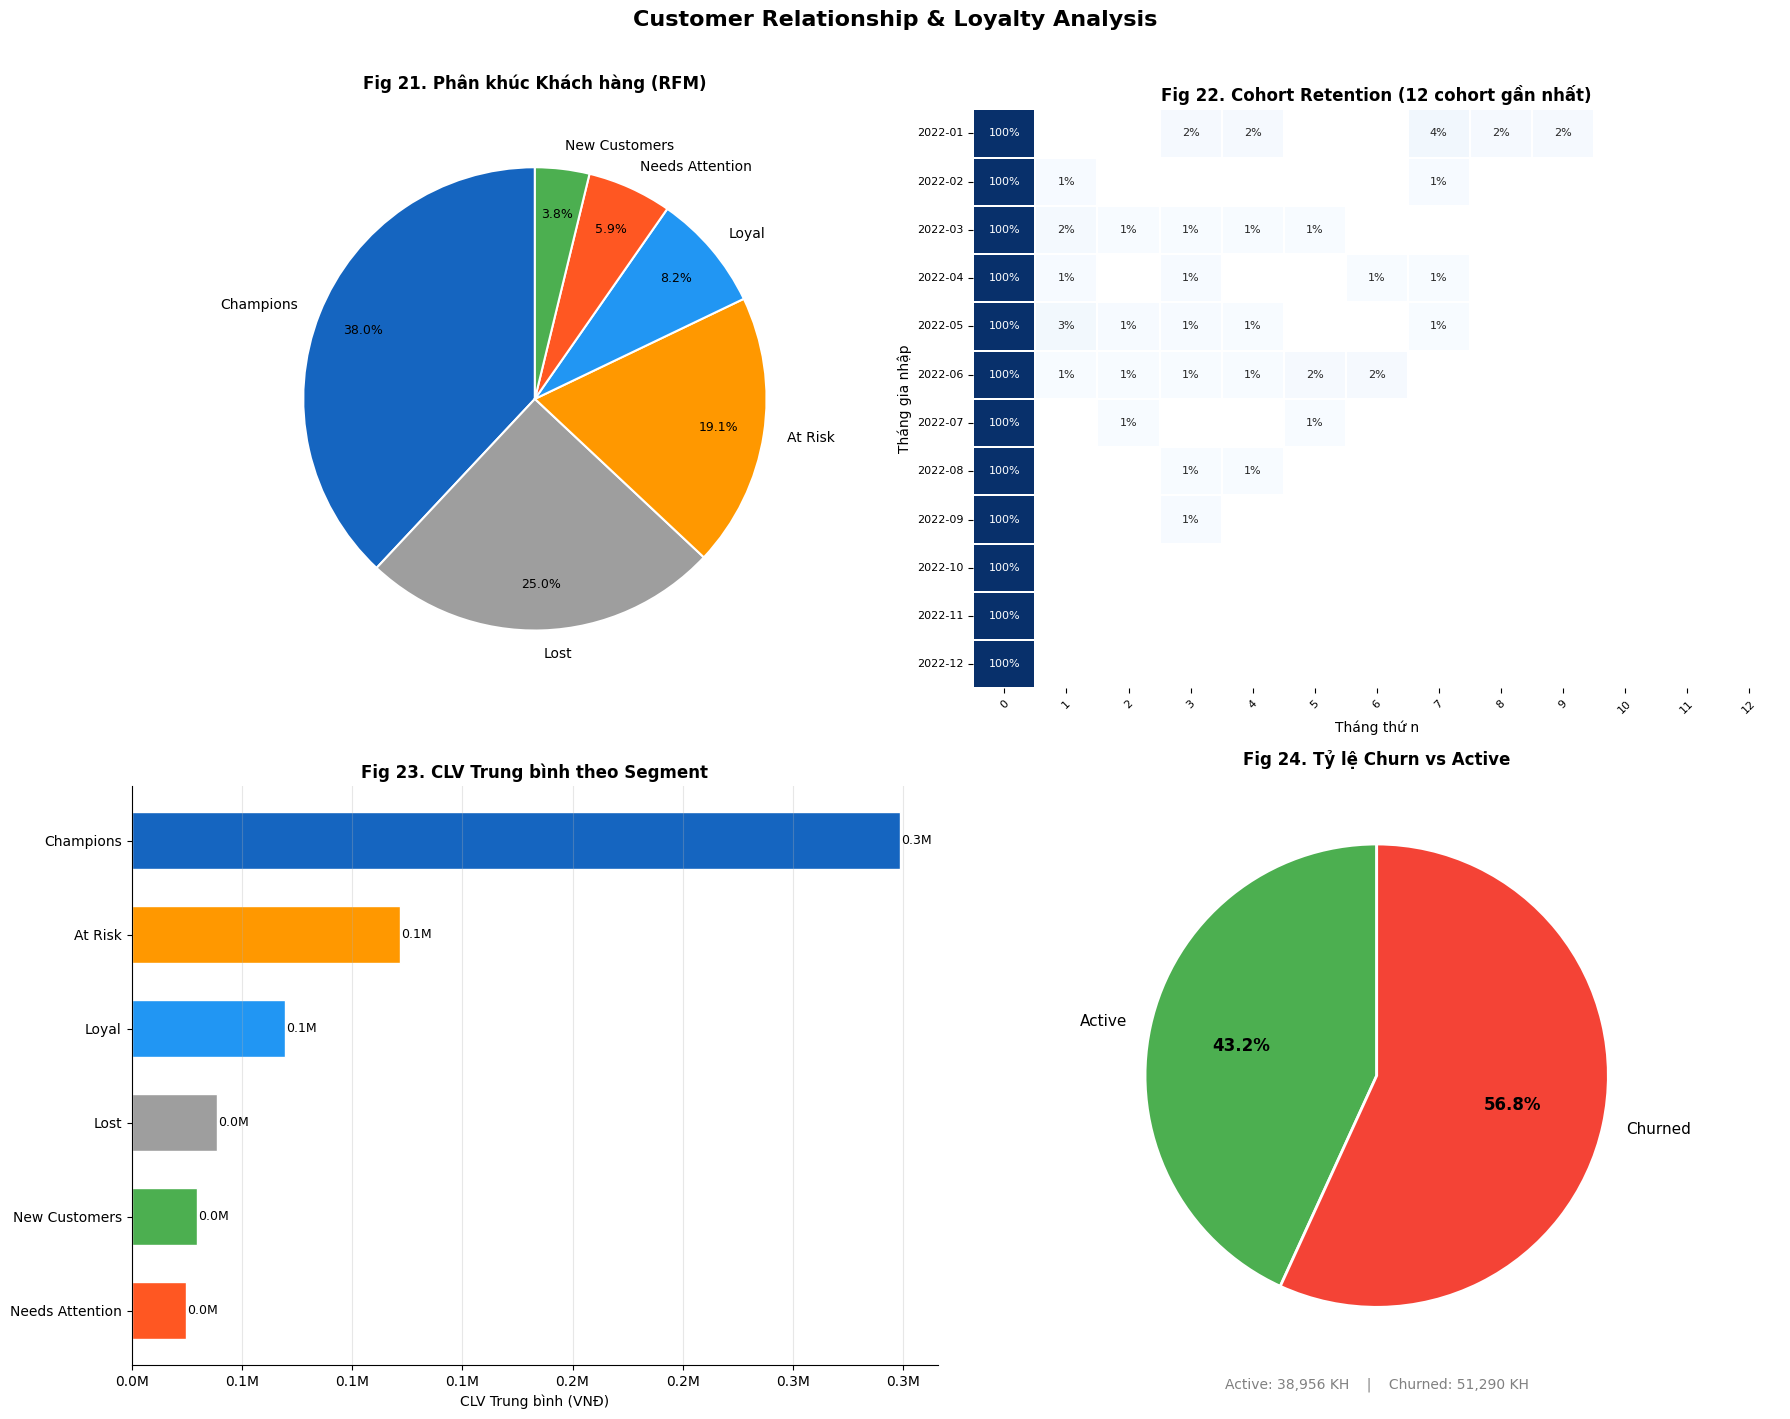


 CUSTOMER SUMMARY
Tổng khách hàng   : 90,246
Active            : 38,956 (43.2%)
Churned           : 51,290 (56.8%)

CLV trung bình    : 173,757 VNĐ
CLV cao nhất      : 3,503,583 VNĐ

Retention tháng 1 : 3.6%
Retention tháng 3 : 3.4%
Retention tháng 6 : 3.2%

--- Phân khúc RFM ---
Segment
Champions          34312
Lost               22553
At Risk            17236
Loyal               7406
Needs Attention     5319
New Customers       3420


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

# ── 0. CHUẨN BỊ DATA ──────────────────────────────────────────────
orders['order_date'] = pd.to_datetime(orders['order_date'])
order_payments = payments.groupby('order_id')['payment_value'].sum().reset_index()

master = (orders
          .merge(order_payments, on='order_id', how='left')
          .merge(customers[['customer_id']], on='customer_id', how='left'))

master['payment_value'] = master['payment_value'].fillna(0)
current_date = master['order_date'].max() + timedelta(days=1)

# ── 1. RFM & SEGMENT ──────────────────────────────────────────────
rfm = master.groupby('customer_id').agg(
    Recency   = ('order_date',    lambda x: (current_date - x.max()).days),
    Frequency = ('order_id',      'count'),
    Monetary  = ('payment_value', 'sum')
).reset_index()

rfm['R'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])

def segment(row):
    r, f = int(row['R']), int(row['F'])
    if r >= 3 and f >= 3:   return 'Champions'
    elif r >= 3 and f >= 2: return 'Loyal'
    elif r >= 3 and f == 1: return 'New Customers'
    elif r == 2 and f >= 2: return 'At Risk'
    elif r == 2 and f == 1: return 'Needs Attention'
    else:                   return 'Lost'

rfm['Segment'] = rfm.apply(segment, axis=1)

# ── 2. CLV ────────────────────────────────────────────────────────
clv = master.groupby('customer_id').agg(
    total_revenue  = ('payment_value', 'sum'),
    order_count    = ('order_id',      'count'),
    last_order     = ('order_date',    'max')
).reset_index()

clv['CLV']            = clv['total_revenue']
clv['days_since_last'] = (current_date - clv['last_order']).dt.days

avg_gap = master.groupby('customer_id')['order_date'] \
                .apply(lambda x: x.sort_values().diff().dt.days.mean())
churn_threshold      = avg_gap.median() * 2
clv['is_churned']    = clv['days_since_last'] > churn_threshold

# ── 3. COHORT RETENTION ───────────────────────────────────────────
master['cohort_month'] = master.groupby('customer_id')['order_date'] \
                               .transform('min').dt.to_period('M')
master['order_month']  = master['order_date'].dt.to_period('M')
master['cohort_index'] = ((master['order_month'].dt.year  - master['cohort_month'].dt.year) * 12 +
                          (master['order_month'].dt.month - master['cohort_month'].dt.month))

cohort_pivot     = master.groupby(['cohort_month','cohort_index'])['customer_id'].nunique().unstack()
retention_matrix = cohort_pivot.divide(cohort_pivot[0], axis=0)

# ── 4. VẼ ─────────────────────────────────────────────────────────
SEG_COLORS = {
    'Champions':       '#1565C0',
    'Loyal':           '#2196F3',
    'New Customers':   '#4CAF50',
    'At Risk':         '#FF9800',
    'Needs Attention': '#FF5722',
    'Lost':            '#9E9E9E'
}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Customer Relationship & Loyalty Analysis', fontsize=16, fontweight='bold', y=1.01)

# ── Fig 21. RFM Segment Pie ────────────────────────────────────────
ax1 = axes[0, 0]
seg_counts = rfm['Segment'].value_counts()
wedges, texts, autotexts = ax1.pie(
    seg_counts,
    labels=seg_counts.index,
    autopct='%1.1f%%',
    colors=[SEG_COLORS[s] for s in seg_counts.index],
    startangle=90,
    pctdistance=0.8,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for t in autotexts: t.set_fontsize(9)
ax1.set_title('Fig 21. Phân khúc Khách hàng (RFM)', fontweight='bold', pad=15)

# ── Fig 22. Cohort Retention Heatmap ──────────────────────────────
ax2 = axes[0, 1]
recent_retention = retention_matrix.iloc[-12:, :13]
sns.heatmap(recent_retention, annot=True, fmt='.0%',
            cmap='Blues', ax=ax2, cbar=False,
            annot_kws={'size': 8}, linewidths=0.3)
ax2.set_title('Fig 22. Cohort Retention (12 cohort gần nhất)', fontweight='bold')
ax2.set_xlabel('Tháng thứ n')
ax2.set_ylabel('Tháng gia nhập')
ax2.tick_params(axis='x', rotation=45, labelsize=8)
ax2.tick_params(axis='y', rotation=0, labelsize=8)

# ── Fig 23. CLV TB theo Segment ───────────────────────────────────
ax3 = axes[1, 0]
clv_seg  = clv.merge(rfm[['customer_id','Segment']], on='customer_id', how='left')
seg_clv  = clv_seg.groupby('Segment')['CLV'].mean().sort_values(ascending=True)
bars = ax3.barh(seg_clv.index, seg_clv.values,
                color=[SEG_COLORS.get(s,'#999') for s in seg_clv.index],
                edgecolor='white', height=0.6)
ax3.set_title('Fig 23. CLV Trung bình theo Segment', fontweight='bold')
ax3.set_xlabel('CLV Trung bình (VNĐ)')
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
for bar, val in zip(bars, seg_clv.values):
    ax3.text(val + 500, bar.get_y() + bar.get_height()/2,
             f'{val/1e6:.1f}M', va='center', fontsize=9)
ax3.grid(axis='x', alpha=0.3)
ax3.spines[['top','right']].set_visible(False)

# ── Fig 24. Churn vs Active ───────────────────────────────────────
ax4 = axes[1, 1]
churn_counts = clv['is_churned'].value_counts()
active  = churn_counts.get(False, 0)
churned = churn_counts.get(True,  0)
wedges, texts, autotexts = ax4.pie(
    [active, churned],
    labels=['Active', 'Churned'],
    colors=['#4CAF50', '#F44336'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
for t in autotexts: t.set_fontsize(12); t.set_fontweight('bold')
ax4.set_title('Fig 24. Tỷ lệ Churn vs Active', fontweight='bold', pad=15)
ax4.text(0, -1.35,
         f'Active: {active:,} KH    |    Churned: {churned:,} KH',
         ha='center', fontsize=10, color='gray')

plt.tight_layout()
plt.show()

# ── 5. SUMMARY ────────────────────────────────────────────────────
print("\n CUSTOMER SUMMARY")
print("="*50)
print(f"Tổng khách hàng   : {len(rfm):,}")
print(f"Active            : {active:,} ({active/len(clv)*100:.1f}%)")
print(f"Churned           : {churned:,} ({churned/len(clv)*100:.1f}%)")
print(f"\nCLV trung bình    : {clv['CLV'].mean():,.0f} VNĐ")
print(f"CLV cao nhất      : {clv['CLV'].max():,.0f} VNĐ")
print(f"\nRetention tháng 1 : {retention_matrix.iloc[:, 1].mean()*100:.1f}%")
print(f"Retention tháng 3 : {retention_matrix.iloc[:, 3].mean()*100:.1f}%")
print(f"Retention tháng 6 : {retention_matrix.iloc[:, 6].mean()*100:.1f}%")
print(f"\n--- Phân khúc RFM ---")
print(rfm['Segment'].value_counts().to_string())

**Fig 21 — Phân khúc Khách hàng (RFM)**

Champions chiếm 38% — con số ấn tượng nhưng cần kiểm chứng kỹ. Với một sàn thời trang, tỷ lệ Champions cao bất thường so với benchmark ngành (~15-20%) gợi ý rằng định nghĩa segment đang khá rộng, hoặc đây thực sự là tệp khách hàng chất lượng cao được nuôi dưỡng tốt — cần đối chiếu với CLV thực tế để xác nhận.
Lost chiếm 25% — 1/4 khách hàng đã rời bỏ hoàn toàn. Với tổng 90,246 khách, con số này tương đương ~22,500 người đã từng mua nhưng không còn phản hồi. Chi phí acquisition để có lại nhóm này thường gấp 5-7 lần chi phí giữ chân — đây là khoản thất thoát ngầm lớn nhất của business.

At Risk (19.1%) + Needs Attention (5.9%) = ~25% khách hàng đang trên đà rời bỏ. Đây là nhóm ưu tiên can thiệp cao nhất vì họ từng có hành vi mua — chi phí kéo lại thấp hơn nhiều so với acquisition mới. Nếu không có action trong 30-60 ngày tới, nhóm này sẽ dịch chuyển sang Lost.

New Customers chỉ 3.8% và Loyal 8.2% — tỷ lệ chuyển đổi từ New → Loyal rất thấp, cho thấy funnel giữ chân sau lần mua đầu đang có vấn đề nghiêm trọng, phù hợp với retention 1-3% từ cohort analysis.


**Fig 22 — Cohort Retention (12 cohort gần nhất)**

Retention tháng 1 chỉ 1-3% — sụp đổ ngay sau lần mua đầu tiên. Đây là con số báo động: trung bình cứ 100 khách mua lần đầu thì chỉ 1-3 người quay lại tháng tiếp theo. Với ngành thời trang vốn có purchase cycle 2-3 tháng/lần, retention tháng 1 thấp là bình thường — nhưng 1-3% vẫn là quá thấp, benchmark ngành tốt thường đạt 8-12%.

Retention tháng 3 (3.4%) và tháng 6 (3.2%) gần như không giảm thêm — đây thực ra là tín hiệu tích cực ẩn: những khách vượt qua được tháng 1-2 có xu hướng trở thành khách trung thành dài hạn. Đây chính là nhóm cần được identify và đầu tư nhiều hơn.

Cohort 2022-01 có retention cao hơn hẳn các cohort khác (4% tháng 4, 2% tháng 5-6) — cần điều tra xem tháng 1/2022 có campaign hay sự kiện đặc biệt gì không, vì đây là best practice có thể replicate cho các cohort tiếp theo.

Các cohort từ 2022-10 đến 2022-12 gần như trắng hoàn toàn — không phải retention tệ mà do chưa đủ thời gian để đo, không nên đánh giá các cohort mới này bằng cùng tiêu chí.


**Fig 23 — CLV Trung bình theo Segment**

Champions có CLV gần 0.3M — gấp 3 lần At Risk và Loyal (gần 0.1M). Khoảng cách này xác nhận phân khúc RFM đang hoạt động đúng: Champions thực sự mang lại giá trị tài chính vượt trội. Với 34,312 Champions × 0.3M CLV = gần 10 tỷ VNĐ doanh thu tiềm năng từ nhóm này.

At Risk có CLV (gần 0.1M) ngang với Loyal — đây là insight quan trọng nhất của biểu đồ này. Nhóm At Risk không phải khách hàng kém giá trị — họ từng chi tiêu tương đương Loyal nhưng đang có dấu hiệu rời bỏ. Mỗi khách At Risk mất đi = mất 0.1M CLV, nhân với 17,236 người = gần 1.7 tỷ VNĐ đang trong vùng nguy hiểm.

Lost, New Customers, Needs Attention đều gần 0.0M — Lost gần bằng 0 xác nhận nhóm này đã không còn đóng góp doanh thu. New Customers thấp là bình thường vì chưa có lịch sử mua đủ dài.


**Fig 24 — Tỷ lệ Churn vs Active**

56.8% khách hàng đã churn — hơn một nửa customer base không còn active. Con số 51,290 khách churned trên tổng 90,246 là mức báo động đỏ: business đang mất khách nhanh hơn tốc độ acquisition. Nếu xu hướng này tiếp tục mà không có intervention, customer base sẽ thu hẹp dần theo thời gian.

43.2% Active (38,956 KH) là nền tảng doanh thu hiện tại — nhưng với retention tháng 1 chỉ 3.6%, ngay cả nhóm Active này cũng đang rất mong manh. Ưu tiên số 1 là bảo vệ nhóm này trước khi nghĩ đến acquisition mới.

Tỷ lệ Churn 56.8% kết hợp với CLV trung bình chỉ 173,757 VNĐ cho thấy vòng đời khách hàng đang rất ngắn — khách mua 1-2 lần rồi rời đi mà không được kéo lại. Đây là dấu hiệu của mô hình kinh doanh đang phụ thuộc quá nhiều vào acquisition thay vì retention.

**KHUYẾN NGHỊ:**

Dựa trên phân khúc khách hàng theo RFM, doanh nghiệp cần ưu tiên các hành động nhằm tối đa hóa giá trị vòng đời (CLV) và giảm churn.

- Trước hết, nhóm At Risk (17,236 khách hàng) cần được ưu tiên cao nhất thông qua các chiến dịch win-back trong vòng 30 ngày, sử dụng email/SMS cá nhân hóa kèm ưu đãi có thời hạn nhằm kích thích quay lại mua hàng. Song song đó, nhóm New Customers (3,420 khách hàng) cần được triển khai onboarding flow theo mốc 7–14–30 ngày sau lần mua đầu để tăng tỷ lệ chuyển đổi sang nhóm Loyal.

- Đối với nhóm Champions (34,312 khách hàng) – nhóm đóng góp giá trị CLV lớn nhất (~10 tỷ VNĐ) – doanh nghiệp nên xây dựng các chương trình loyalty độc quyền nhằm giữ chân và gia tăng tần suất mua hàng.

- Ở mức ưu tiên trung bình, nhóm Needs Attention (5,319 khách hàng) cần được kích hoạt lại bằng các ưu đãi reactivation trước khi họ chuyển sang trạng thái Lost.

- Cuối cùng, với nhóm Lost (22,553 khách hàng), doanh nghiệp chỉ nên triển khai các chiến dịch remarketing chi phí thấp và tránh đầu tư lớn, do chi phí thu hút lại nhóm này cao và hiệu quả thấp.

Tổng thể, chiến lược nên tập trung vào giữ chân và tái kích hoạt khách hàng hiện có thay vì phụ thuộc quá nhiều vào việc thu hút khách hàng mới.

### Key takeaway:
- Promotion kém hiệu quả: Đang chạy ngược mùa và giảm giá đại trà gây lỗ. Cần: Chỉ tập trung Discount vào Top 20% sản phẩm trong mùa cao điểm (Q3-Q4).

- Điểm chạm Thanh toán: Credit Card nắm giữ >50% doanh thu. Cần: Tối ưu tuyệt đối luồng Checkout và đẩy mạnh Trả góp vào cuối năm để tăng AOV.

- Báo động Retention: 56% khách đã rời bỏ; tỷ lệ quay lại tháng đầu cực thấp (1-3%). Cần: Thiết lập ngay quy trình chăm sóc tự động (Onboarding) sau lần mua đầu.

- Cứu vãn doanh thu: Nhóm At Risk đang đe dọa mất 1.7 tỷ VNĐ. Cần: Chiến dịch Win-back (kéo khách quay lại) gấp trong 30 ngày.

**KẾT LUẬN:**

Dịch chuyển trọng tâm: Chuyển từ "Đốt tiền tìm khách mới" sang "Tái kích hoạt khách cũ" và "Tối ưu tỷ lệ chuyển đổi checkout"

## **2.3. Inventory**

In [ ]:
# ── 0. CHUẨN BỊ DATA ──────────────────────────────────────────────
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
inventory['month']   = inventory['snapshot_date'].dt.to_period('M')
inventory['quarter'] = inventory['snapshot_date'].dt.to_period('Q')
inventory['year']    = inventory['snapshot_date'].dt.year

# Bỏ các cột đã có trong inventory trước khi merge để tránh _x _y
cols_to_add = ['product_id', 'size', 'color', 'price', 'cogs']
master_inv = inventory.merge(products[cols_to_add], on='product_id', how='left')

# Kiểm tra lại
print(master_inv.columns.tolist())

['snapshot_date', 'product_id', 'stock_on_hand', 'units_received', 'units_sold', 'stockout_days', 'days_of_supply', 'fill_rate', 'stockout_flag', 'overstock_flag', 'reorder_flag', 'sell_through_rate', 'product_name', 'category', 'segment', 'year', 'month', 'month_year', 'quarter', 'size', 'color', 'price', 'cogs']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── 0. CHUẨN BỊ DATA ──────────────────────────────────────────────
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
inventory['month']   = inventory['snapshot_date'].dt.to_period('M')
inventory['quarter'] = inventory['snapshot_date'].dt.to_period('Q')
inventory['year']    = inventory['snapshot_date'].dt.year

# inventory đã có sẵn category, chỉ lấy thêm size/color/price/cogs
cols_to_add = ['product_id', 'size', 'color', 'price', 'cogs']
master_inv = inventory.merge(products[cols_to_add], on='product_id', how='left')

# Kiểm tra
print(master_inv.columns.tolist())
print("Rows:", len(master_inv))

['snapshot_date', 'product_id', 'stock_on_hand', 'units_received', 'units_sold', 'stockout_days', 'days_of_supply', 'fill_rate', 'stockout_flag', 'overstock_flag', 'reorder_flag', 'sell_through_rate', 'product_name', 'category', 'segment', 'year', 'month', 'month_year', 'quarter', 'size', 'color', 'price', 'cogs']
Rows: 60247


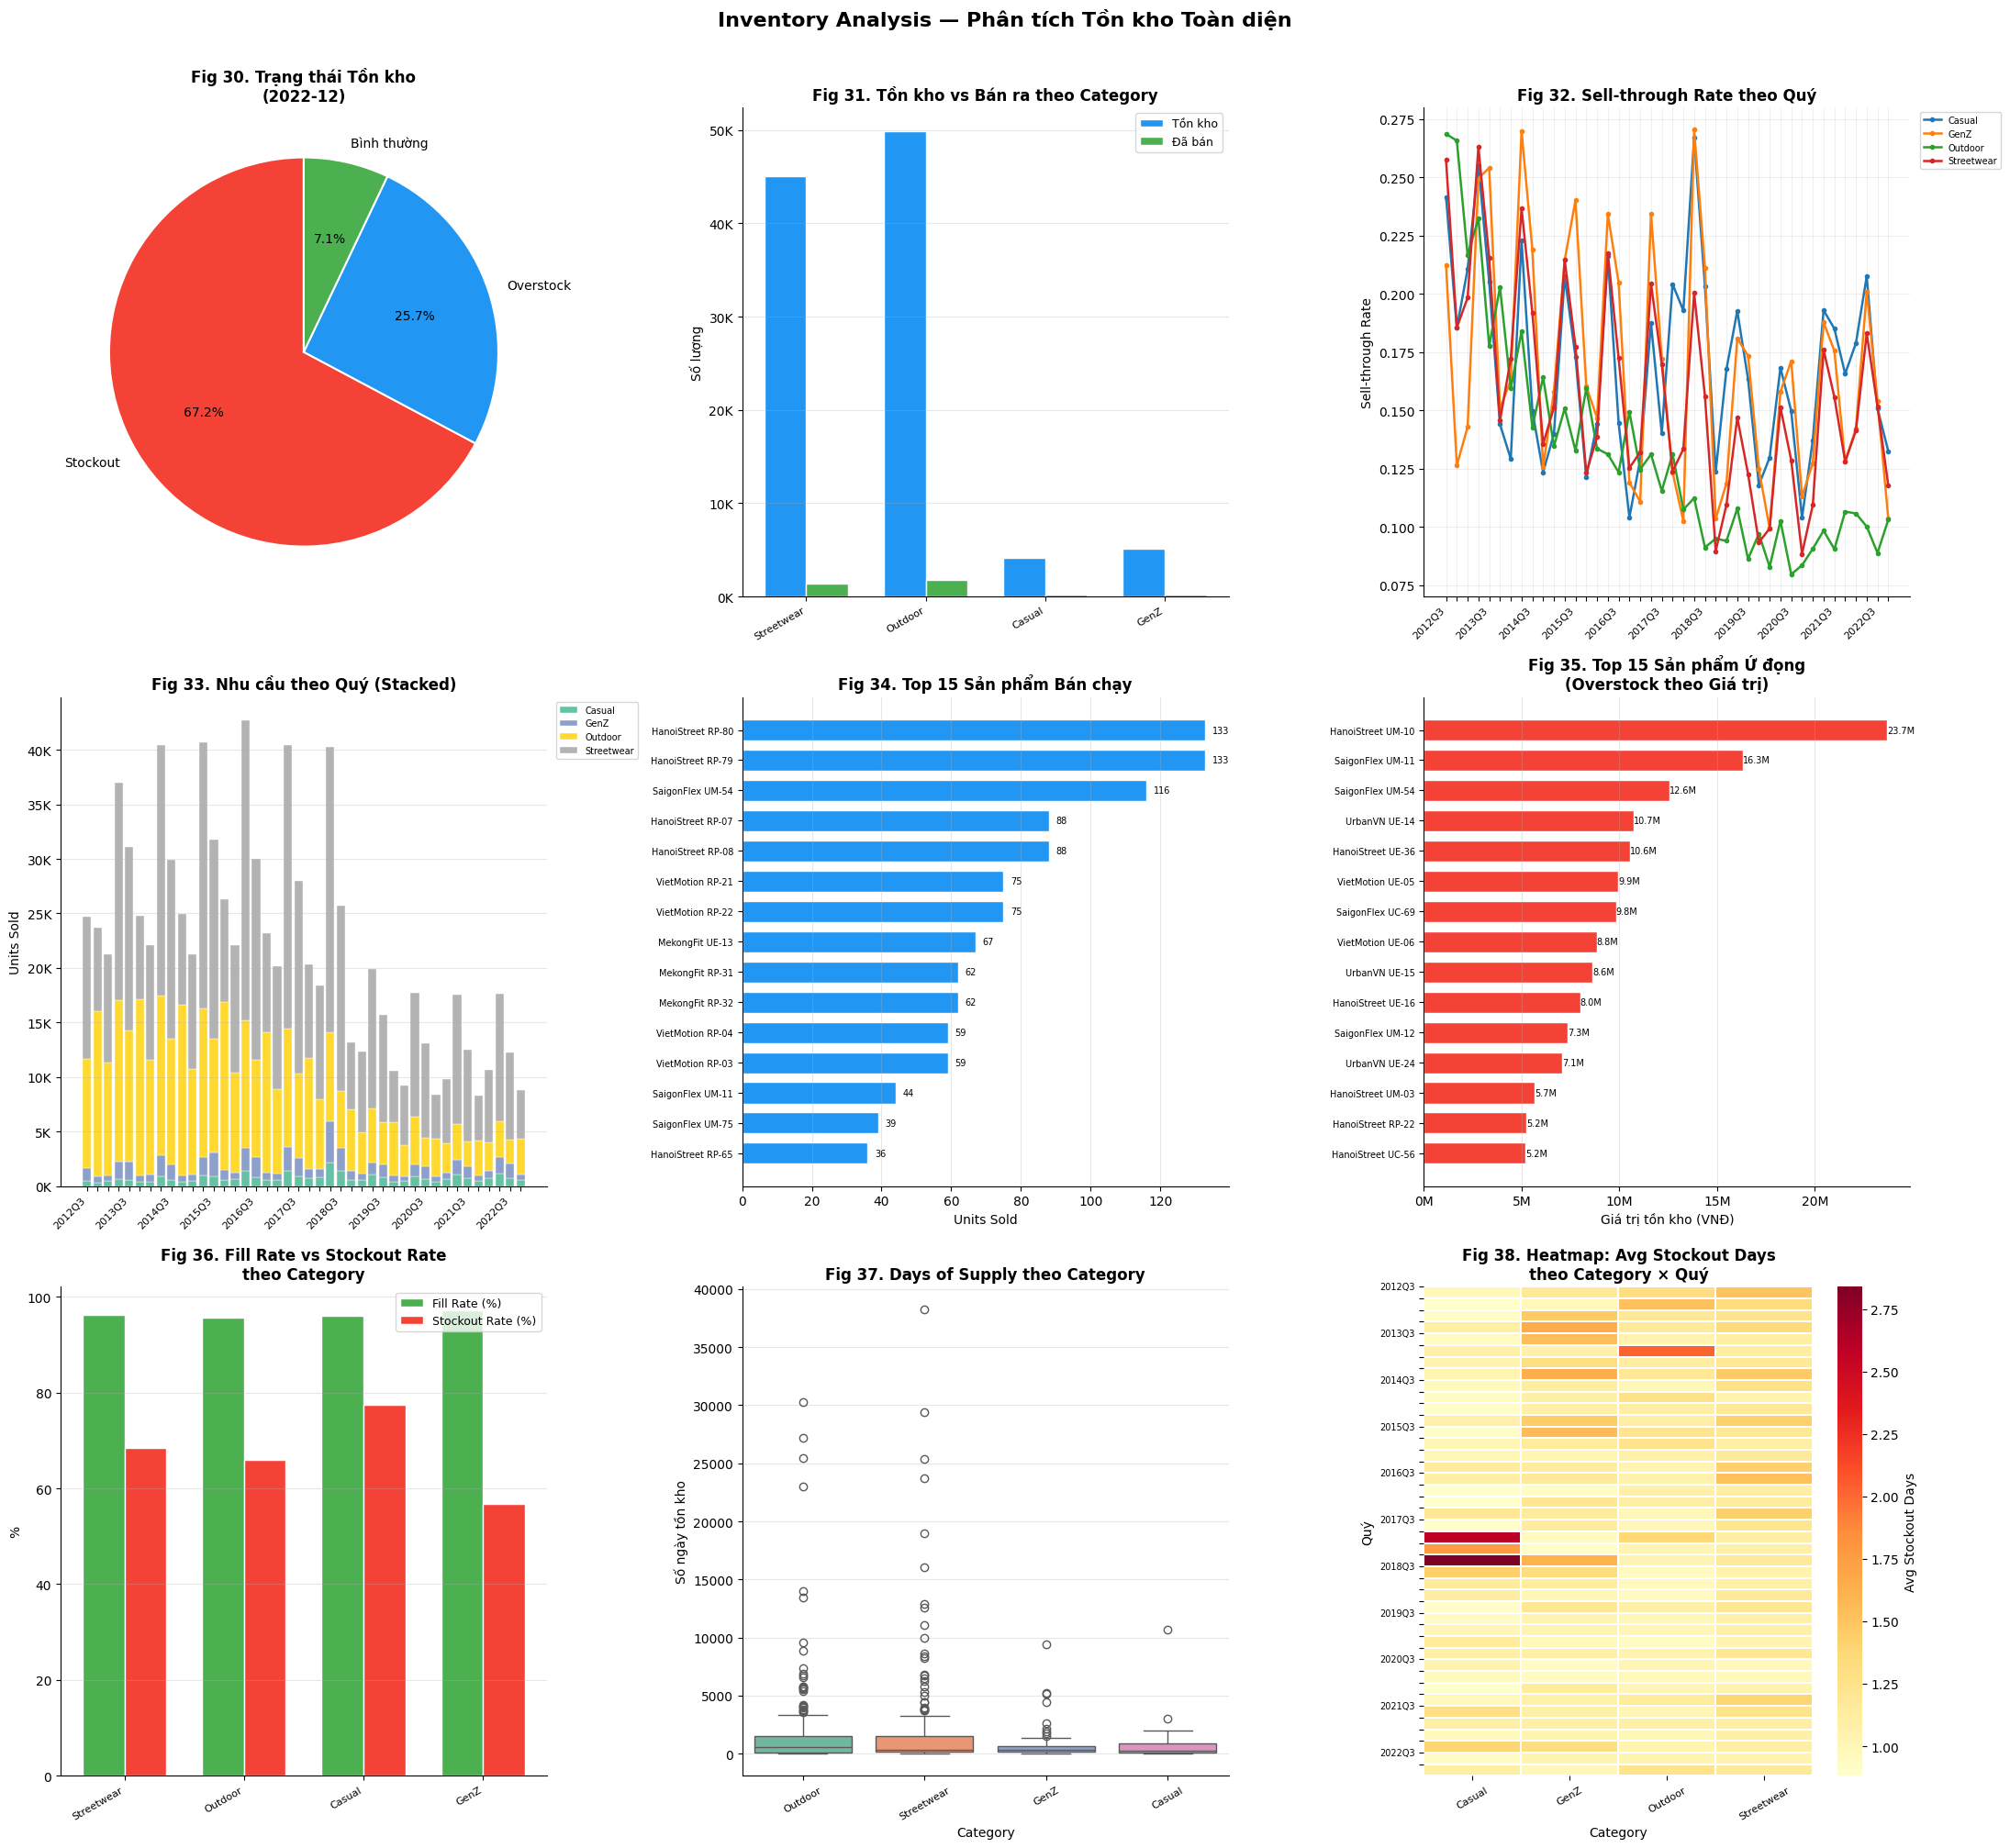


📦 INVENTORY SUMMARY
Snapshot mới nhất     : 2022-12-31
Tổng SKU              : 424

--- Trạng thái ---
  Stockout       : 285 SKU (67.2%)
  Overstock      : 109 SKU (25.7%)
  Bình thường    : 30 SKU (7.1%)

--- Giá trị tồn kho ---
  Tổng inventory value : 387,629,923 VNĐ
  Overstock value      : 382,864,400 VNĐ

--- Hiệu suất ---
  Fill rate TB         : 96.1%
  Sell-through TB      : 11.8%
  Avg days of supply   : 1869.2 ngày
  Avg stockout days    : 1.2 ngày/tháng

--- Theo Category ---
  category  stock_on_hand  units_sold  fill_rate  stockout_rate  inventory_value
Streetwear          45085        1379   0.962247       0.683673     2.763657e+08
   Outdoor          49929        1797   0.956715       0.659722     8.821425e+07
    Casual           4095         190   0.960833       0.775000     1.598633e+07
      GenZ           5126         199   0.971970       0.568182     7.063594e+06


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── 0. CHUẨN BỊ DATA ──────────────────────────────────────────────
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
inventory['month']   = inventory['snapshot_date'].dt.to_period('M')
inventory['quarter'] = inventory['snapshot_date'].dt.to_period('Q')
inventory['year']    = inventory['snapshot_date'].dt.year

# inventory đã có sẵn category/product_name/segment → chỉ lấy thêm size/color/price/cogs
master_inv = inventory.merge(
    products[['product_id', 'size', 'color', 'price', 'cogs']],
    on='product_id', how='left'
)

# Tháng gần nhất
latest_month = master_inv['snapshot_date'].max()
latest_inv   = master_inv[master_inv['snapshot_date'] == latest_month].copy()

# ── 1. CHỈ SỐ BỔ SUNG ─────────────────────────────────────────────
latest_inv['inventory_value']   = latest_inv['stock_on_hand'] * latest_inv['cogs']
latest_inv['revenue_potential'] = latest_inv['stock_on_hand'] * latest_inv['price']
master_inv['inventory_value']   = master_inv['stock_on_hand'] * master_inv['cogs']

def inv_status(row):
    if row['stockout_flag'] == 1:    return 'Stockout'
    elif row['overstock_flag'] == 1: return 'Overstock'
    elif row['reorder_flag'] == 1:   return 'Cần tái đặt'
    else:                            return 'Bình thường'

latest_inv['inv_status'] = latest_inv.apply(inv_status, axis=1)

# ── 2. AGGREGATIONS ───────────────────────────────────────────────
# Nhu cầu theo quý & category
demand_trend = (master_inv
    .groupby(['quarter', 'category'])['units_sold']
    .sum().reset_index())

# Sell-through theo quý & category
sellthrough_trend = (master_inv
    .groupby(['quarter', 'category'])['sell_through_rate']
    .mean().reset_index())

# Tổng hợp theo category
geo_inv = (latest_inv.groupby('category').agg(
    stock_on_hand   = ('stock_on_hand',    'sum'),
    units_sold      = ('units_sold',       'sum'),
    stockout_rate   = ('stockout_flag',    'mean'),
    overstock_rate  = ('overstock_flag',   'mean'),
    fill_rate       = ('fill_rate',        'mean'),
    inventory_value = ('inventory_value',  'sum')
).reset_index().sort_values('inventory_value', ascending=False))

# Top 15 bán chạy
top_sellers = (latest_inv
    .groupby(['product_id', 'product_name', 'category']).agg(
        units_sold    = ('units_sold',       'sum'),
        sell_through  = ('sell_through_rate','mean'),
        inv_value     = ('inventory_value',  'sum')
    ).reset_index()
    .sort_values('units_sold', ascending=False)
    .head(15))

# Top 15 ứ đọng
slow_movers = (latest_inv[latest_inv['overstock_flag'] == 1]
    .groupby(['product_id', 'product_name', 'category']).agg(
        stock           = ('stock_on_hand',    'sum'),
        inventory_value = ('inventory_value',  'sum'),
        sell_through    = ('sell_through_rate','mean'),
        days_of_supply  = ('days_of_supply',   'mean')
    ).reset_index()
    .sort_values('inventory_value', ascending=False)
    .head(15))

quarters_str = [str(q) for q in demand_trend['quarter'].unique()]

# ── 3. VẼ ─────────────────────────────────────────────────────────
STATUS_COLORS = {
    'Bình thường': '#4CAF50',
    'Cần tái đặt': '#FF9800',
    'Overstock':   '#2196F3',
    'Stockout':    '#F44336'
}
PALETTE = plt.cm.Set2(np.linspace(0, 1, len(geo_inv)))

fig = plt.figure(figsize=(22, 20))
fig.suptitle('Inventory Analysis — Phân tích Tồn kho Toàn diện',
             fontsize=16, fontweight='bold', y=1.005)

# ── Fig 30. Trạng thái tồn kho ────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
status_counts = latest_inv['inv_status'].value_counts()
ax1.pie(status_counts,
        labels=status_counts.index,
        autopct='%1.1f%%',
        colors=[STATUS_COLORS[s] for s in status_counts.index],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax1.set_title(f'Fig 30. Trạng thái Tồn kho\n({latest_month.strftime("%Y-%m")})',
              fontweight='bold')

# ── Fig 31. Tồn kho vs Bán ra theo Category ──────────────────────
ax2 = fig.add_subplot(3, 3, 2)
x = np.arange(len(geo_inv))
w = 0.35
ax2.bar(x - w/2, geo_inv['stock_on_hand'], w,
        label='Tồn kho', color='#2196F3', edgecolor='white')
ax2.bar(x + w/2, geo_inv['units_sold'], w,
        label='Đã bán', color='#4CAF50', edgecolor='white')
ax2.set_title('Fig 31. Tồn kho vs Bán ra theo Category', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(geo_inv['category'], rotation=30, ha='right', fontsize=8)
ax2.set_ylabel('Số lượng')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

# ── Fig 32. Sell-through Rate theo Quý ───────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
pivot_st = sellthrough_trend.pivot(
    index='quarter', columns='category', values='sell_through_rate')
qs = [str(q) for q in pivot_st.index]
for col in pivot_st.columns:
    ax3.plot(range(len(qs)), pivot_st[col],
             marker='o', markersize=3, linewidth=1.8, label=col)
ax3.set_title('Fig 32. Sell-through Rate theo Quý', fontweight='bold')
ax3.set_ylabel('Sell-through Rate')
ax3.set_xticks(range(len(qs)))
ax3.set_xticklabels(
    [q if i % 4 == 0 else '' for i, q in enumerate(qs)],
    rotation=45, ha='right', fontsize=8)
ax3.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
ax3.grid(alpha=0.2)
ax3.spines[['top','right']].set_visible(False)

# ── Fig 33. Nhu cầu Stacked Bar theo Quý ─────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
pivot_demand = demand_trend.pivot(
    index='quarter', columns='category', values='units_sold')
qs2 = [str(q) for q in pivot_demand.index]
cats = pivot_demand.columns.tolist()
PAL  = plt.cm.Set2(np.linspace(0, 1, len(cats)))
bottom = None
for i, cat in enumerate(cats):
    vals = pivot_demand[cat].values
    ax4.bar(range(len(qs2)), vals, bottom=bottom,
            label=cat, color=PAL[i], edgecolor='white', linewidth=0.3)
    bottom = vals if bottom is None else bottom + vals
ax4.set_title('Fig 33. Nhu cầu theo Quý (Stacked)', fontweight='bold')
ax4.set_ylabel('Units Sold')
ax4.set_xticks(range(len(qs2)))
ax4.set_xticklabels(
    [q if i % 4 == 0 else '' for i, q in enumerate(qs2)],
    rotation=45, ha='right', fontsize=8)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax4.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
ax4.grid(axis='y', alpha=0.3)
ax4.spines[['top','right']].set_visible(False)

# ── Fig 34. Top 15 bán chạy ───────────────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)
ts = top_sellers.sort_values('units_sold', ascending=True)
bars = ax5.barh(ts['product_name'], ts['units_sold'],
                color='#2196F3', edgecolor='white', height=0.7)
ax5.set_title('Fig 34. Top 15 Sản phẩm Bán chạy', fontweight='bold')
ax5.set_xlabel('Units Sold')
for bar, val in zip(bars, ts['units_sold']):
    ax5.text(val + 2, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=7)
ax5.tick_params(axis='y', labelsize=7)
ax5.grid(axis='x', alpha=0.3)
ax5.spines[['top','right']].set_visible(False)

# ── Fig 35. Top 15 ứ đọng ─────────────────────────────────────────
ax6 = fig.add_subplot(3, 3, 6)
sm = slow_movers.sort_values('inventory_value', ascending=True)
bars = ax6.barh(sm['product_name'], sm['inventory_value'],
                color='#F44336', edgecolor='white', height=0.7)
ax6.set_title('Fig 35. Top 15 Sản phẩm Ứ đọng\n(Overstock theo Giá trị)',
              fontweight='bold')
ax6.set_xlabel('Giá trị tồn kho (VNĐ)')
ax6.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.0f}M'))
for bar, val in zip(bars, sm['inventory_value']):
    ax6.text(val + 1000, bar.get_y() + bar.get_height()/2,
             f'{val/1e6:.1f}M', va='center', fontsize=7)
ax6.tick_params(axis='y', labelsize=7)
ax6.grid(axis='x', alpha=0.3)
ax6.spines[['top','right']].set_visible(False)

# ── Fig 36. Fill Rate vs Stockout Rate ───────────────────────────
ax7 = fig.add_subplot(3, 3, 7)
x = np.arange(len(geo_inv))
ax7.bar(x - w/2, geo_inv['fill_rate'] * 100, w,
        label='Fill Rate (%)', color='#4CAF50', edgecolor='white')
ax7.bar(x + w/2, geo_inv['stockout_rate'] * 100, w,
        label='Stockout Rate (%)', color='#F44336', edgecolor='white')
ax7.set_title('Fig 36. Fill Rate vs Stockout Rate\ntheo Category',
              fontweight='bold')
ax7.set_xticks(x)
ax7.set_xticklabels(geo_inv['category'], rotation=30, ha='right', fontsize=8)
ax7.set_ylabel('%')
ax7.legend(fontsize=9)
ax7.grid(axis='y', alpha=0.3)
ax7.spines[['top','right']].set_visible(False)

# ── Fig 37. Days of Supply Boxplot ───────────────────────────────
ax8 = fig.add_subplot(3, 3, 8)
cat_order = (latest_inv.groupby('category')['days_of_supply']
             .median().sort_values(ascending=False).index)
sns.boxplot(data=latest_inv, x='category', y='days_of_supply',
            order=cat_order, ax=ax8, palette='Set2')
ax8.set_title('Fig 37. Days of Supply theo Category', fontweight='bold')
ax8.set_xlabel('Category')
ax8.set_ylabel('Số ngày tồn kho')
ax8.tick_params(axis='x', rotation=30, labelsize=8)
ax8.grid(axis='y', alpha=0.3)
ax8.spines[['top','right']].set_visible(False)

# ── Fig 38. Heatmap Stockout Days ────────────────────────────────
ax9 = fig.add_subplot(3, 3, 9)
heat_stockout = (master_inv
    .groupby(['quarter', 'category'])['stockout_days']
    .mean().unstack())
heat_stockout.index = heat_stockout.index.astype(str)
sns.heatmap(heat_stockout, cmap='YlOrRd', ax=ax9,
            annot=False, linewidths=0.2,
            cbar_kws={'label': 'Avg Stockout Days'})
ax9.set_title('Fig 38. Heatmap: Avg Stockout Days\ntheo Category × Quý',
              fontweight='bold')
ax9.set_xlabel('Category')
ax9.set_ylabel('Quý')
n = len(heat_stockout.index)
ax9.set_yticks(np.arange(n)) # Added to set the number of y-ticks
ax9.set_yticklabels(
    [heat_stockout.index[i] if i % 4 == 0 else ''
     for i in range(n)],
    rotation=0, fontsize=7)
ax9.tick_params(axis='x', rotation=30, labelsize=8)

plt.tight_layout()
plt.show()

# ── 4. SUMMARY ────────────────────────────────────────────────────
status_counts = latest_inv['inv_status'].value_counts()
print("\n📦 INVENTORY SUMMARY")
print("="*55)
print(f"Snapshot mới nhất     : {latest_month.strftime('%Y-%m-%d')}")
print(f"Tổng SKU              : {len(latest_inv):,}")
print(f"\n--- Trạng thái ---")
for status, count in status_counts.items():
    print(f"  {status:<15}: {count:,} SKU ({count/len(latest_inv)*100:.1f}%)")
print(f"\n--- Giá trị tồn kho ---")
print(f"  Tổng inventory value : {latest_inv['inventory_value'].sum():,.0f} VNĐ")
print(f"  Overstock value      : {latest_inv[latest_inv['overstock_flag']==1]['inventory_value'].sum():,.0f} VNĐ")
print(f"\n--- Hiệu suất ---")
print(f"  Fill rate TB         : {latest_inv['fill_rate'].mean()*100:.1f}%")
print(f"  Sell-through TB      : {latest_inv['sell_through_rate'].mean()*100:.1f}%")
print(f"  Avg days of supply   : {latest_inv['days_of_supply'].mean():.1f} ngày")
print(f"  Avg stockout days    : {latest_inv['stockout_days'].mean():.1f} ngày/tháng")
print(f"\n--- Theo Category ---")
print(geo_inv[['category','stock_on_hand','units_sold',
               'fill_rate','stockout_rate','inventory_value']]
      .to_string(index=False))

**PHÂN TÍCH:**

**A. Sự mất cân đối nghiêm trọng trong cấu trúc tồn kho: **

Tỷ lệ Stockout "báo động": Theo Fig 30, có tới 67.2% danh mục sản phẩm đang ở trạng thái Stockout (cháy hàng), trong khi chỉ có 7.1% ở mức bình thường. Điều này cho thấy doanh nghiệp đang đánh mất một lượng doanh thu khổng lồ do không có hàng để bán.

Nghịch lý Overstock (25.7%): Dù cháy hàng diện rộng, vẫn có hơn 1/4 danh mục bị tồn kho quá mức. Fig 31 và 35 chỉ ra rằng nhóm Outdoor và Streetwear chiếm tỷ trọng tồn kho cực lớn (hơn 40k-50k đơn vị) nhưng lượng bán ra thực tế (Đã bán) lại vô cùng nhỏ bé so với số lượng tồn.

**B. Hiệu suất luân chuyển hàng hóa (Sell-through Rate) sụt giảm:**

Nhìn vào Fig 32, tỷ lệ Sell-through (bán hết) của tất cả các ngành hàng (Casual, GenZ, Outdoor, Streetwear) đều có xu hướng giảm mạnh từ giai đoạn 2018-2019 trở đi.

Đặc biệt, nhóm Outdoor luôn có tỷ lệ Sell-through thấp nhất (thường nằm dưới đáy biểu đồ Fig 32). Điều này khớp với Fig 37, nơi nhóm Outdoor và Streetwear có nhiều "outliers" (điểm dị biệt) với số ngày tồn kho lên đến hơn 30.000 - 35.000 ngày — một con số không tưởng, tương đương với hàng chục năm tồn kho.

**C. Rủi ro tài chính từ các "Sản phẩm ứ đọng:"**
Fig 35 liệt kê danh sách các sản phẩm đang "giam" vốn. Top đầu là sản phẩm HanoiStreet UM-10 và SaigonFlex UM-11 với giá trị tồn kho lần lượt là 23.7M VNĐ và 16.3M VNĐ.

Trong khi đó, biểu đồ Fig 34 (Bán chạy) lại gọi tên các sản phẩm khác hoàn toàn. Sự lệch pha giữa "Thứ khách hàng cần" và "Thứ doanh nghiệp đang có trong kho" là rất lớn.

**D. Fill Rate vs. Stockout Rate (Fig 36):**
Mặc dù Fill Rate (tỷ lệ đáp ứng đơn hàng) nhìn chung có vẻ cao (trên 80-90%), nhưng Stockout Rate của các nhóm như Casual và Streetwear lại vọt lên rất cao (khoảng 60-80%). Điều này ám chỉ rằng hệ thống đang ưu tiên đáp ứng những đơn hàng lẻ tẻ nhưng lại thường xuyên hết hàng ở những dòng sản phẩm chủ lực.

**KHUYẾN NGHỊ:**
**Giai đoạn 1: Giải phóng dòng tiền (Cắt lỗ):**

- Thanh lý hàng tồn (Liquidation): Đối với các sản phẩm trong Fig 35 (Top 15 ứ đọng) và nhóm Outdoor có số ngày tồn trên 1000 ngày, cần thực hiện các chương trình khuyến mãi sâu (Flash sale, xả kho, combo) để thu hồi vốn ngay lập tức.

- Ngừng nhập nhóm hàng kém hiệu quả: Tạm dừng nhập mới các sản phẩm thuộc category Outdoor cho đến khi tỷ lệ Sell-through cải thiện.

**Giai đoạn 2: Tối ưu hóa vận hành (Cân bằng):**
Phân loại ABC/XYZ:

- Nhóm A (Bán chạy - Fig 34): Cần thiết lập mức tồn kho an toàn (Safety Stock) cao hơn và tần suất đặt hàng dày hơn để tránh Stockout 67.2% như hiện tại.

- Nhóm C (Ứ đọng - Fig 35): Chuyển sang mô hình đặt hàng theo yêu cầu hoặc giảm tối đa định mức tồn kho.

- Cải thiện dự báo nhu cầu (Demand Forecasting): Fig 33 cho thấy nhu cầu theo quý biến động mạnh nhưng đang có xu hướng giảm dần. Cần sử dụng dữ liệu bán hàng gần nhất (2021-2022) để dự báo, thay vì dựa vào các chỉ số cũ từ 2015-2017.

**Giai đoạn 3: Hệ thống hóa:**

- Rà soát quy trình mua hàng: Tại sao nhóm Outdoor lại có lượng tồn kho khổng lồ (Fig 31) trong khi sức bán cực thấp? Cần kiểm tra lại khâu thu mua (Procurement) để xem có sự sai lệch trong dự báo hay sai lầm trong lựa chọn sản phẩm không phù hợp với thị hiếu.

- Cảnh báo sớm: Thiết lập hệ thống Dashboard cảnh báo khi sản phẩm chạm ngưỡng 90 ngày không phát sinh đơn hàng để xử lý sớm, tránh để tình trạng tồn kho lên đến hàng nghìn ngày như hiện nay.

Tóm lại: Doanh nghiệp cần "vứt bỏ gánh nặng" ở nhóm Outdoor và Streetwear đang ứ đọng để "dồn lực" đáp ứng nhu cầu đang bị bỏ lỡ ở các nhóm sản phẩm bán chạy. Nếu không giải quyết 67% tỷ lệ Stockout, doanh nghiệp sẽ tiếp tục mất thị phần vào tay đối thủ.

# **TỔNG KẾT**

Phân tích dữ liệu toàn diện này đã đi sâu vào các khía cạnh khác nhau trong hoạt động kinh doanh, từ xu hướng doanh thu tổng thể đến chi tiết về sản phẩm, khách hàng và quản lý tồn kho. Các phát hiện chính và khuyến nghị chiến lược được tóm tắt như sau:

## **1. Xu hướng doanh thu**

*   **Giai đoạn 2012-2018:** Doanh thu tăng trưởng mạnh mẽ, với các đỉnh cao hơn theo thời gian, cho thấy giai đoạn mở rộng thị trường và thu hút khách hàng thành công.
*   **Giai đoạn 2019-2022:** Doanh thu sụt giảm nghiêm trọng và đi ngang ở mức thấp, với các đỉnh giảm gần 50% so với giai đoạn trước. Sự sụt giảm này xảy ra đồng thời với sự gia tăng mạnh mẽ của lưu lượng truy cập web (Web Traffic), cho thấy vấn đề không nằm ở việc thiếu tiếp cận khách hàng mà là ở khả năng chuyển đổi hoặc giữ chân. Dù Web Traffic tăng, tỷ lệ chuyển đổi và doanh thu lại giảm, ám chỉ một vấn đề nội tại nghiêm trọng thay vì yếu tố vĩ mô (như Covid-19) ảnh hưởng đến toàn ngành.

## **Danh mục sản phẩm**

*   **Streetwear:** Hiện tại là "bò sữa" (Cash Cow) của doanh nghiệp, chiếm phần lớn cả sản lượng (55%) và doanh thu (80%). Mặc dù tạo ra biên lợi nhuận cao, Streetwear có tính thời vụ rất mạnh và đang trong giai đoạn suy thoái sau 2019, không còn là động lực tăng trưởng chính.
*   **Outdoor:** Được phân loại là "chó mực" (Dog) với thị phần thấp và tăng trưởng âm (-4.37%). Sản lượng và doanh thu liên tục suy giảm, biên lợi nhuận thấp, cho thấy đây là danh mục không hiệu quả và cần cân nhắc cắt giảm hoặc loại bỏ.
*   **Casual & GenZ:** Cả hai đều là "dấu hỏi" (Question Mark) với thị phần thấp nhưng tốc độ tăng trưởng cao (Casual: 16.43%, GenZ: 11.69%). Đây là những danh mục có tiềm năng lớn, ít bị ảnh hưởng bởi tính thời vụ và các yếu tố vĩ mô, cần được đầu tư mạnh để trở thành "ngôi sao" (Star).


**Biên lợi nhuận:** GenZ có biên lợi nhuận cao nhất (20.18%), trong khi Casual thấp nhất (9.55%). Điều này cho thấy hiệu quả chuyển đổi doanh thu thành lợi nhuận của GenZ tốt hơn Casual.


**Tính mùa vụ:** Doanh thu và COGS biến động mạnh theo mùa, với các đỉnh vào giữa năm và đáy vào cuối năm. Sự phụ thuộc lớn vào Streetwear (có tính mùa vụ cao) khiến doanh thu không ổn định. Cần "san phẳng" doanh thu bằng cách phát triển các dòng sản phẩm ít tính thời vụ hơn như Casual và GenZ.

## **2. Phân tích khách hàng**

*   **Promotion:** Các chiến dịch khuyến mãi không hiệu quả, không đồng pha với xu hướng doanh thu và giảm giá sâu không cứu được các sản phẩm yếu. Doanh nghiệp cần chuyển đổi sang các chương trình giảm giá chiến lược, tập trung vào các sản phẩm bán chạy và thời điểm đỉnh cao, đồng thời tìm kiếm các cách kích cầu khác.
*   **Phương thức thanh toán:** Credit Card là phương thức chủ đạo (50-55% giao dịch/doanh thu). Thị phần của các phương thức gần như phẳng trong 10 năm, cho thấy doanh nghiệp chưa chủ động định hướng hành vi thanh toán. Apple Pay và Bank Transfer có giá trị giao dịch trung bình cao hơn nhưng volume thấp. **Khuyến nghị:** Tối ưu hóa quy trình thanh toán Credit Card, đẩy mạnh các tùy chọn trả góp vào mùa cao điểm, tái kích hoạt người dùng PayPal và cải thiện trải nghiệm mobile checkout.
*   **Quan hệ & Lòng trung thành khách hàng (CRM & Loyalty):** Tỷ lệ churn rất cao (56.8%), với hơn một nửa khách hàng đã không còn hoạt động. Retention tháng đầu tiên cực thấp (1-3%). Các phân khúc RFM cho thấy Champions (38%) mang lại giá trị cao, nhưng At Risk (19.1%) và Needs Attention (5.9%) là nhóm cần ưu tiên can thiệp để ngăn chặn churn. **Khuyến nghị:** Tập trung vào các chiến dịch "win-back" cho nhóm At Risk, chương trình onboarding cho New Customers, và loyalty độc quyền cho Champions. Giảm đầu tư vào việc thu hút lại nhóm Lost.

## **4. Hàng tồn kho**

*   **Nghịch lý tồn kho:** Tỷ lệ Stockout rất cao (67.2%) nhưng đồng thời có 25.7% danh mục bị Overstock (tồn kho quá mức). Điều này cho thấy sự mất cân đối nghiêm trọng giữa nguồn cung và cầu.
*   **Hiệu suất luân chuyển (Sell-through Rate):** Giảm mạnh từ 2018-2019, đặc biệt ở nhóm Outdoor và Streetwear, với nhiều sản phẩm có số ngày tồn kho không tưởng (hàng chục nghìn ngày).
*   **Rủi ro tài chính:** Các sản phẩm "ứ đọng" (ví dụ: HanoiStreet UM-10, SaigonFlex UM-11) đang "giam" vốn lớn. **Khuyến nghị:**
    *   **Giai đoạn 1 (Cắt lỗ):** Thanh lý hàng tồn kho dư thừa (đặc biệt là Outdoor và các sản phẩm trong Top 15 ứ đọng) thông qua các chương trình khuyến mãi sâu. Tạm dừng nhập hàng các nhóm kém hiệu quả.
    *   **Giai đoạn 2 (Cân bằng):** Phân loại sản phẩm (ABC/XYZ) để thiết lập mức tồn kho an toàn và tần suất đặt hàng phù hợp. Cải thiện dự báo nhu cầu dựa trên dữ liệu gần nhất.
    *   **Giai đoạn 3 (Hệ thống hóa):** Rà soát quy trình mua hàng để tránh sai lệch dự báo và thiết lập hệ thống cảnh báo sớm để xử lý hàng tồn đọng kịp thời.

## **Tóm lại:**

Doanh nghiệp đang đối mặt với những thách thức lớn về doanh thu giảm sút, hiệu quả sản phẩm và quản lý tồn kho yếu kém, cùng với tỷ lệ churn khách hàng cao. Cần một chiến lược chuyển đổi mạnh mẽ, tập trung vào:

1.  **Chuyển dịch danh mục sản phẩm:** Giảm sự phụ thuộc vào Streetwear và Outdoor, đầu tư mạnh vào các danh mục tiềm năng như Casual và GenZ để thúc đẩy tăng trưởng bền vững hơn.
2.  **Tối ưu hóa chiến lược Marketing & Bán hàng:** Cải thiện hiệu quả các chiến dịch khuyến mãi, tối ưu hóa trải nghiệm thanh toán và ưu tiên các chương trình giữ chân khách hàng để giảm churn và tăng CLV.
3.  **Cải thiện quản lý chuỗi cung ứng:** Giải quyết nghịch lý tồn kho bằng cách thanh lý hàng dư thừa và cải thiện dự báo nhu cầu để giảm tình trạng cháy hàng, tối ưu hóa vốn lưu động và đảm bảo nguồn cung phù hợp với nhu cầu thị trường.